# Machine Learning Analysis of PBMC Gene Expression in Parkinson's Disease

## Project Overview

This project investigates the use of machine learning to analyse peripheral
blood mononuclear cell (PBMC) gene-expression patterns associated with
Parkinson's disease.

The study also serves as a case study in the importance of independent
validation in high-dimensional biomedical machine learning. A model showing
very strong performance within a small development cohort is evaluated on an
independent PBMC transcriptomic dataset generated using a different microarray
platform.

Rather than assuming that strong internal performance demonstrates
generalisability, the project examines whether the learned expression patterns
reproduce across cohorts and investigates potential sources of cross-dataset
variation when external performance differs.

### Objectives

1. Explore and preprocess PBMC gene-expression data from Parkinson's disease
   and control samples.
2. Develop a leakage-conscious machine-learning classification pipeline.
3. Evaluate internal performance using repeated stratified cross-validation
   and permutation testing.
4. Investigate feature-selection stability and biological annotation.
5. Evaluate the model using an independent Parkinson's disease PBMC cohort.
6. Examine cross-platform and cross-dataset differences that may affect
   generalisability.
7. Discuss the limitations of predictive modelling using small,
   high-dimensional biomedical datasets.

This project is exploratory and is not intended to provide a clinical
diagnostic model or establish causal biomarkers for Parkinson's disease.

## Datasets

### Development Dataset — GSE22491

- **Source:** NCBI Gene Expression Omnibus (GEO)
- **Accession:** GSE22491
- **Biological material:** Peripheral blood mononuclear cells (PBMCs)
- **Samples:** 18 (10 Parkinson's disease, 8 healthy controls)
- **Platform:** Agilent whole-human-genome microarray
- **Purpose in this project:** Model development and internal validation

### External Validation Dataset — GSE100054

- **Source:** NCBI Gene Expression Omnibus (GEO)
- **Accession:** GSE100054
- **Biological material:** Peripheral blood mononuclear cells (PBMCs)
- **Samples:** 19 (10 Parkinson's disease, 9 healthy controls)
- **Platform:** Affymetrix Human Clariom D Assay
- **Purpose in this project:** Independent external validation

The datasets were generated using different microarray platforms, providing
a challenging test of whether patterns learned from the development cohort
generalise to an independent cohort.

> This project is an exploratory data science portfolio project and is not
> intended to develop or validate a clinical diagnostic tool.

In [125]:
# Data handling and numerical analysis
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# File handling and downloads
import urllib.request
import gzip
import shutil
import csv
from io import StringIO
from collections import Counter

# Machine learning
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    permutation_test_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Statistical analysis
from statsmodels.stats.multitest import multipletests

# Display settings
pd.set_option("display.max_columns", 20)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Acquisition

Gene expression data were obtained from the NCBI Gene Expression Omnibus (GEO)
under accession **GSE22491**.

The dataset contains gene expression measurements from peripheral blood
mononuclear cells (PBMCs) collected from individuals with Parkinson's disease
and healthy controls.

The processed expression matrix is downloaded directly from GEO to make the
analysis reproducible.

In [126]:
# Download the processed GSE22491 expression matrix from NCBI GEO


url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE22nnn/GSE22491/matrix/GSE22491_series_matrix.txt.gz"

compressed_file = "GSE22491_series_matrix.txt.gz"
expression_file = "GSE22491_series_matrix.txt"

urllib.request.urlretrieve(url, compressed_file)

with gzip.open(compressed_file, "rb") as f_in:
    with open(expression_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Dataset downloaded and extracted successfully.")

Dataset downloaded and extracted successfully.


## 2. Initial Data Inspection

Before preprocessing, the GEO series matrix was inspected to understand its
structure, metadata, sample information, and gene expression measurements.

In [127]:
# Display the first 40 lines of the GEO series matrix

with open(expression_file, "r") as file:
    for i in range(40):
        print(file.readline().strip())

!Series_title	"Transcriptomic profiling of peripheral blood mononuclear cells from patients with Parkinson’s disease and control subjects."
!Series_geo_accession	"GSE22491"
!Series_status	"Public on Mar 20 2012"
!Series_submission_date	"Jun 22 2010"
!Series_last_update_date	"Jan 23 2019"
!Series_pubmed_id	"20096956"
!Series_summary	"To get insight into systemic molecular events associated with Parkinson’s disease (PD), an age-related neurodegenerative disorder, we compared gene expression patterns of peripheral blood mononuclear cells (PBMC) derived from elderly healthy controls and from PD patients."
!Series_overall_design	"Transcriptomic profiling of patients with Parkinson’s disease and control subjects. RNA were extracted  from peripheral mononuclear blood cells and were hybridized on 4x44k Agilent expression microarrays."
!Series_type	"Expression profiling by array"
!Series_contributor	"Marie-Christine,,Chartier-Harlin"
!Series_sample_id	"GSM558679 GSM558680 GSM558681 GSM558682 GS

## 3. Gene Expression Matrix

The GEO series matrix contains both experimental metadata and gene expression
measurements. The expression table was extracted separately for analysis.

Rows initially represent microarray probes, while columns represent individual
biological samples.

In [128]:
# Find the location of the expression matrix within the GEO file

with open(expression_file, "r") as file:
    lines = file.readlines()

start_index = next(
    i for i, line in enumerate(lines)
    if line.startswith("!series_matrix_table_begin")
)

end_index = next(
    i for i, line in enumerate(lines)
    if line.startswith("!series_matrix_table_end")
)

print("Expression matrix starts at line:", start_index)
print("Expression matrix ends at line:", end_index)
print("Number of matrix lines:", end_index - start_index - 1)

Expression matrix starts at line: 58
Expression matrix ends at line: 41060
Number of matrix lines: 41001


In [129]:
# Load the expression matrix into a pandas DataFrame

matrix_text = "".join(lines[start_index + 1:end_index])

expression_df = pd.read_csv(
    StringIO(matrix_text),
    sep="\t",
    index_col=0
)

print("Expression matrix shape:", expression_df.shape)

expression_df.head()

Expression matrix shape: (41000, 18)


,GSM558679,GSM558680,GSM558681,GSM558682,GSM558683,GSM558684,GSM558685,GSM558686,GSM558687,GSM558688,GSM558689,GSM558690,GSM558691,GSM558692,GSM558693,GSM558694,GSM558695,GSM558696
ID_REF,,,,,,,,,,,,,,,,,,
A_23_P100001,70.45531,74.08276,163.00340,60.26153,86.88167,59.98058,54.79351,94.92616,63.50280,77.363650,230.92200,100.50210,35.49662,94.55115,34.52267,29.82176,117.018200,109.11230
A_23_P100011,36.05924,51.25579,44.08363,27.68379,29.08192,27.11753,33.61845,37.87051,19.86293,28.975470,43.04949,27.92689,27.77922,27.17462,42.66582,35.39824,30.863040,59.28417
A_23_P100022,15.89111,41.16017,71.74736,20.73850,61.11377,46.92745,86.47705,28.90795,20.63744,17.559910,52.44994,32.84772,28.33225,54.03454,28.80620,10.72072,9.470333,80.74634
A_23_P100056,13.05220,94.65132,69.98246,84.56211,35.44921,1258.60100,48.30520,105.49330,32.15351,6.119446,39.85040,28.80519,26.24564,41.18601,25.01945,77.27700,53.907240,38.46672
A_23_P100074,910.59900,950.09040,630.97710,675.33730,812.34830,690.58200,901.76340,1009.08600,957.69080,794.563400,803.26130,760.57070,697.15770,943.80610,1011.60800,951.57890,680.615300,844.40870


## 4. Data Restructuring

The original expression matrix contains microarray probes as rows and biological
samples as columns. For machine learning, the matrix was transposed so that each
row represents one biological sample and each column represents an expression
feature.

In [130]:
# Transpose the expression matrix

X = expression_df.T.copy()

print("Original shape:", expression_df.shape)
print("Transposed shape:", X.shape)

X.head()

Original shape: (41000, 18)
Transposed shape: (18, 41000)


ID_REF,A_23_P100001,A_23_P100011,A_23_P100022,A_23_P100056,A_23_P100074,A_23_P100092,A_23_P100103,A_23_P100111,A_23_P100127,A_23_P100133,...,A_32_P99715,A_32_P99744,A_32_P99753,A_32_P99804,A_32_P99825,A_32_P9986,A_32_P99864,A_32_P99902,A_32_P99933,A_32_P99942
GSM558679,70.45531,36.05924,15.89111,13.05220,910.5990,177.0861,182.1707,106.76470,19.04417,67.26103,...,108.7368,4.502431,49.13556,142.8577,4.365150,4.421224,4.662829,758.2933,19.369380,4.310185
GSM558680,74.08276,51.25579,41.16017,94.65132,950.0904,170.3158,222.9690,90.87226,40.31244,100.46410,...,151.7138,3.419751,32.99755,151.9679,3.510171,3.605404,10.054510,859.2449,3.646630,3.428708
GSM558681,163.00340,44.08363,71.74736,69.98246,630.9771,172.6499,232.0265,54.65690,21.63110,100.34470,...,132.1237,4.215271,25.16496,143.3123,4.407940,4.416751,4.764653,749.2661,4.827171,4.359487
GSM558682,60.26153,27.68379,20.73850,84.56211,675.3373,151.6727,147.7298,76.87310,31.71230,88.74558,...,106.5989,3.102159,44.93699,135.4111,3.891894,4.780159,9.364401,687.3708,3.654252,3.692589
GSM558683,86.88167,29.08192,61.11377,35.44921,812.3483,200.8457,139.8214,84.88863,35.38390,89.93017,...,140.8674,3.541468,40.47195,102.2466,4.374210,5.155768,7.457107,976.1731,8.012067,4.151985


In [131]:
# Extract sample titles from GEO metadata

sample_title_line = next(
    line for line in lines
    if line.startswith("!Sample_title")
)

sample_titles = sample_title_line.strip().split("\t")[1:]
sample_titles = [title.strip('"') for title in sample_titles]

sample_info = pd.DataFrame({
    "Sample_ID": X.index,
    "Sample_Title": sample_titles
})

sample_info

,Sample_ID,Sample_Title
0,GSM558679,Control sample N°1
1,GSM558680,Control sample N°2
2,GSM558681,Control sample N°3
3,GSM558682,Control sample N°4
4,GSM558683,Control sample N°5
5,GSM558684,Control sample N°6
6,GSM558685,Control sample N°7
7,GSM558686,Control sample N°8
8,GSM558687,PD sample # A
9,GSM558688,PD sample # B


In [132]:
# Derive disease labels from the GEO sample metadata

sample_info["Group"] = sample_info["Sample_Title"].apply(
    lambda title: "Control" if title.lower().startswith("control") else "Parkinson's"
)

sample_info

,Sample_ID,Sample_Title,Group
0,GSM558679,Control sample N°1,Control
1,GSM558680,Control sample N°2,Control
2,GSM558681,Control sample N°3,Control
3,GSM558682,Control sample N°4,Control
4,GSM558683,Control sample N°5,Control
5,GSM558684,Control sample N°6,Control
6,GSM558685,Control sample N°7,Control
7,GSM558686,Control sample N°8,Control
8,GSM558687,PD sample # A,Parkinson's
9,GSM558688,PD sample # B,Parkinson's


In [133]:
# Check the number of samples in each group

sample_info["Group"].value_counts()

,count
Group,
Parkinson's,10
Control,8


## 5. Data Quality Assessment

Before preprocessing and modelling, the expression matrix was assessed for
missing values, duplicate features, data types, and overall value distribution.

These checks help identify potential data-quality issues and determine the
appropriate preprocessing strategy.

In [134]:
# Basic data quality checks

print("Number of samples:", X.shape[0])
print("Number of expression features:", X.shape[1])

print("\nTotal missing values:", X.isna().sum().sum())

print("Duplicate feature IDs:", X.columns.duplicated().sum())

print("All features numeric:", all(
    pd.api.types.is_numeric_dtype(X[col]) for col in X.columns
))

print("\nExpression value range:")
print("Minimum:", X.min().min())
print("Maximum:", X.max().max())

Number of samples: 18
Number of expression features: 41000

Total missing values: 0
Duplicate feature IDs: 0
All features numeric: True

Expression value range:
Minimum: 2.154463
Maximum: 535086.9


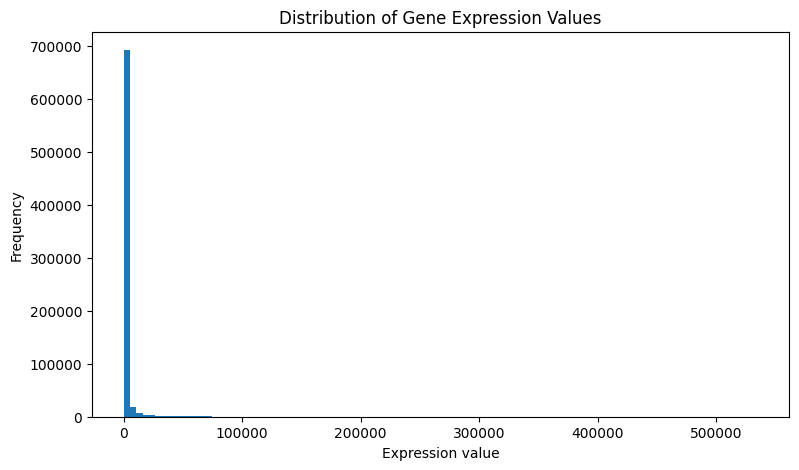

In [135]:
# Examine the distribution of expression values


expression_values = X.to_numpy().flatten()

plt.figure(figsize=(9, 5))
plt.hist(expression_values, bins=100)

plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [136]:
# Summary statistics across all expression measurements

pd.Series(expression_values).describe()

,0
count,738000.000000
mean,2430.601587
std,14396.478976
min,2.154463
25%,5.194587
50%,64.054175
75%,554.703125
max,535086.900000


## 6. Expression Data Transformation

The raw expression measurements showed a strongly right-skewed distribution,
with a small number of very large values. A log2 transformation was therefore
applied to compress the dynamic range and reduce the influence of extreme
expression values.

The transformation preserves the relative ordering of expression measurements
while producing a distribution more suitable for exploratory analysis and
machine learning.

In [137]:
# Apply log2 transformation

X_log = np.log2(X)

print("Original expression range:")
print("Minimum:", X.min().min())
print("Maximum:", X.max().max())

print("\nLog2-transformed expression range:")
print("Minimum:", X_log.min().min())
print("Maximum:", X_log.max().max())

Original expression range:
Minimum: 2.154463
Maximum: 535086.9

Log2-transformed expression range:
Minimum: 1.1073283223170016
Maximum: 19.029413683741662


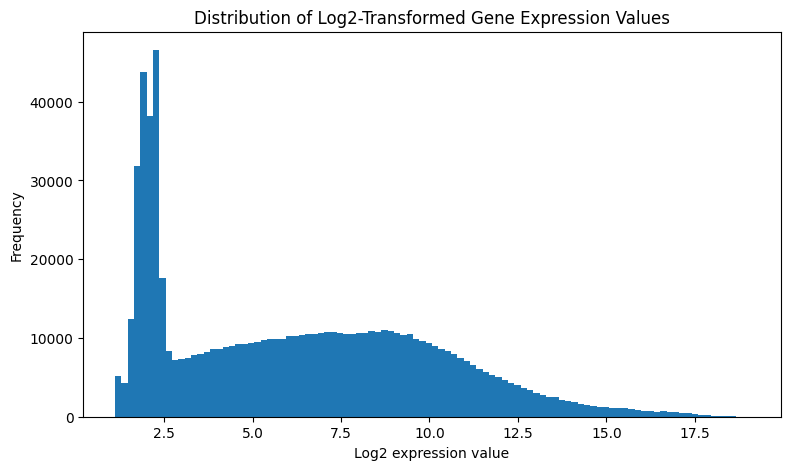

In [138]:
# Visualise the distribution after log2 transformation

log_expression_values = X_log.to_numpy().flatten()

plt.figure(figsize=(9, 5))
plt.hist(log_expression_values, bins=100)

plt.xlabel("Log2 expression value")
plt.ylabel("Frequency")
plt.title("Distribution of Log2-Transformed Gene Expression Values")

plt.show()

In [139]:
# Summary statistics after log2 transformation

pd.Series(log_expression_values).describe()

,0
count,738000.000000
mean,6.287374
std,3.759209
min,1.107328
25%,2.377009
50%,6.001221
75%,9.115572
max,19.029414


## 7. Exploratory Analysis with Principal Component Analysis

Principal Component Analysis (PCA) was used to explore broad patterns in the
high-dimensional expression data.

PCA reduces thousands of expression features into a smaller number of
components that capture major sources of variation between samples. Disease
labels were used only to colour the visualisation and were not used to fit the
PCA model.

Because this dataset contains substantially more features than samples, the PCA
results are treated as exploratory rather than evidence of diagnostic
separation.

In [140]:
# Standardise expression features before PCA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

# Reduce the expression data to two principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)

print("\nExplained variance:")
print("PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print(
    "Total:",
    round(pca.explained_variance_ratio_[:2].sum() * 100, 2),
    "%"
)

PCA output shape: (18, 2)

Explained variance:
PC1: 25.64 %
PC2: 16.34 %
Total: 41.99 %


In [141]:
# Create a DataFrame containing PCA coordinates and sample labels

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Group": sample_info["Group"].values,
    "Sample_ID": sample_info["Sample_ID"].values
})

pca_df.head()

,PC1,PC2,Group,Sample_ID
0,127.969062,37.891076,Control,GSM558679
1,147.487576,-36.064187,Control,GSM558680
2,113.997238,35.537758,Control,GSM558681
3,47.856946,20.131934,Control,GSM558682
4,100.175751,-8.119815,Control,GSM558683


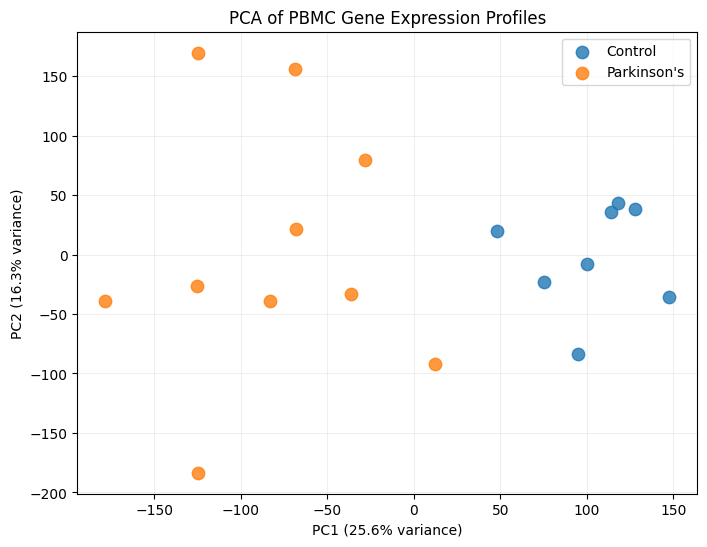

In [142]:
# Visualise samples in PCA space

plt.figure(figsize=(8, 6))

for group in pca_df["Group"].unique():
    subset = pca_df[pca_df["Group"] == group]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=80,
        alpha=0.8
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("PCA of PBMC Gene Expression Profiles")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### PCA Interpretation

The first two principal components explained approximately 42% of the total
variance in the standardised expression data. PC1 accounted for 25.6% and PC2
for 16.3%.

The PCA visualisation showed substantial separation between the Parkinson's
disease and control samples, particularly along PC1. This suggests that disease
status may be associated with a major source of variation in the PBMC
transcriptomic profiles.

However, the dataset contains only 18 samples and PCA is an exploratory,
unsupervised technique. The observed separation therefore should not be
interpreted as evidence of diagnostic performance. Potential biological and
technical confounding factors may also contribute to the observed structure.

## 8. Unsupervised Variance Filtering

The dataset contains substantially more expression features than biological
samples. As an initial dimensionality-reduction step, features with very low
variation across samples were removed.

This filtering step is unsupervised: disease labels are not used to determine
which features are retained. This reduces the number of uninformative features
before subsequent modelling while avoiding label-based feature selection at
this stage.

In [143]:
# Calculate the variance of each expression feature

feature_variance = X_log.var(axis=0)

feature_variance.describe()

,0
count,41000.000000
mean,0.355630
std,0.644169
min,0.007319
25%,0.083920
50%,0.167623
75%,0.401825
max,35.947106


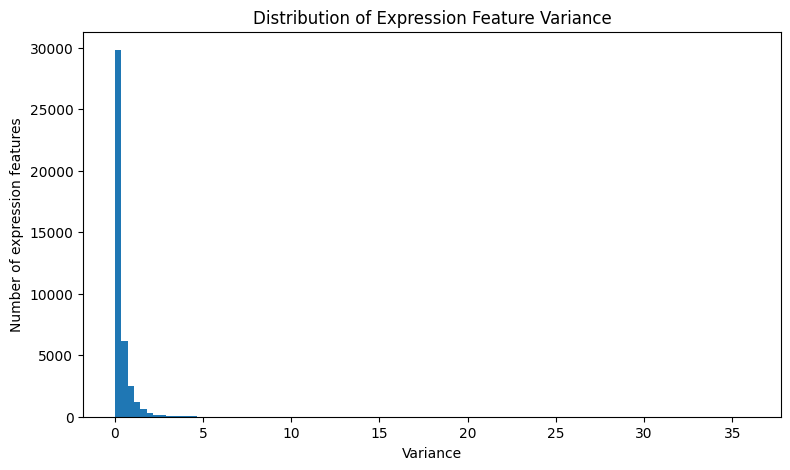

In [144]:
# Visualise the distribution of feature variances

plt.figure(figsize=(9, 5))

plt.hist(feature_variance, bins=100)

plt.xlabel("Variance")
plt.ylabel("Number of expression features")
plt.title("Distribution of Expression Feature Variance")

plt.show()

In [145]:
# Examine variance percentiles

feature_variance.quantile([
    0.00,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00
])

,0
0.00,0.007319
0.25,0.083920
0.50,0.167623
0.75,0.401825
0.90,0.831830
0.95,1.221917
0.99,2.456646
1.00,35.947106


### Variance Filtering Strategy

To reduce dimensionality, the top 10% most variable expression features were
retained for subsequent analysis. The threshold was defined using the 90th
percentile of feature variance.

This is an unsupervised filtering step because disease labels were not used to
select features. The purpose is to remove relatively invariant probes while
retaining features that capture greater variation between samples.

Given the small sample size, this threshold is treated as a pragmatic
exploratory choice rather than a biologically established cut-off.

In [146]:
# Retain the top 10% most variable expression features

variance_threshold = feature_variance.quantile(0.90)

selected_features = feature_variance[
    feature_variance >= variance_threshold
].index

X_var = X_log[selected_features].copy()

print("Variance threshold:", round(variance_threshold, 4))
print("Features before filtering:", X_log.shape[1])
print("Features after filtering:", X_var.shape[1])
print("Samples:", X_var.shape[0])

Variance threshold: 0.8318
Features before filtering: 41000
Features after filtering: 4100
Samples: 18


In [147]:
# Create the target variable

y = sample_info.set_index("Sample_ID").loc[X_var.index, "Group"]

print(y.value_counts())

Group
Parkinson's    10
Control         8
Name: count, dtype: int64


## 9. Leakage-Safe Machine Learning Pipeline

A machine-learning pipeline was constructed to evaluate whether PBMC expression
profiles contain predictive information for distinguishing Parkinson's disease
samples from healthy controls.

Because the dataset contains only 18 samples and thousands of expression
features, particular care was taken to reduce the risk of overfitting and data
leakage.

Supervised feature selection and feature standardisation were performed inside
each cross-validation training fold. Therefore, information from validation
samples was not used when selecting the features used to train the classifier.

Logistic Regression was used as an initial baseline classifier.

In [148]:
# Build a leakage-safe modelling pipeline
logistic_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif, k=50)),
    ("scaling", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

print(logistic_pipeline)

Pipeline(steps=[('feature_selection', SelectKBest(k=50)),
                ('scaling', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=5000))])


In [149]:
# Repeated stratified cross-validation

cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=20,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1_macro",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_var,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Cross-validation completed.")

Cross-validation completed.


In [150]:
# Summarise cross-validation performance

metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

for metric in metrics:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

accuracy: 1.000 ± 0.000
balanced_accuracy: 1.000 ± 0.000
f1: 1.000 ± 0.000
roc_auc: 1.000 ± 0.000


### Methodological Refinement

The initial pipeline produced perfect cross-validation performance. Given the
very small sample size and high dimensionality of the dataset, this result was
treated cautiously rather than interpreted as evidence of perfect predictive
performance.

Although the initial variance filtering did not use disease labels, the
variance threshold was calculated using the complete dataset before
cross-validation. To make the evaluation more conservative, all data-dependent
feature filtering, scaling, and supervised feature selection were subsequently
performed within each cross-validation training fold.

In [151]:
# More conservative pipeline:
# all data-dependent preprocessing occurs within cross-validation

strict_pipeline = Pipeline([
    ("variance_filter", VarianceThreshold(threshold=0.1)),
    ("feature_selection", SelectKBest(score_func=f_classif, k=50)),
    ("scaling", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

strict_results = cross_validate(
    strict_pipeline,
    X_log,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for metric in metrics:
    scores = strict_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

accuracy: 1.000 ± 0.000
balanced_accuracy: 1.000 ± 0.000
f1: 1.000 ± 0.000
roc_auc: 1.000 ± 0.000


## 10. Permutation Testing

The cross-validation analysis produced perfect classification performance.
Given the very small sample size and high dimensionality of the dataset, this
result requires cautious evaluation.

A permutation test was therefore used to assess whether the observed
classification performance was substantially greater than would be expected
when disease labels are randomly assigned.

The Parkinson's disease and control labels were repeatedly shuffled while the
expression measurements were kept unchanged. The complete machine-learning
pipeline was then evaluated using the same cross-validation strategy.

In [152]:
# Use a single stratified CV scheme for the permutation test to keep
# computation manageable and the permutation comparison well-defined.
permutation_cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=5,
    random_state=42
)

score, permutation_scores, pvalue = permutation_test_score(
    strict_pipeline,
    X_log,
    y,
    scoring="balanced_accuracy",
    cv=permutation_cv,
    n_permutations=100,
    random_state=42,
    n_jobs=-1
)

print("Observed balanced accuracy:", round(score, 3))
print("Mean permuted accuracy:", round(permutation_scores.mean(), 3))
print("Permutation p-value:", round(pvalue, 4))

Observed balanced accuracy: 1.0
Mean permuted accuracy: 0.474
Permutation p-value: 0.0099


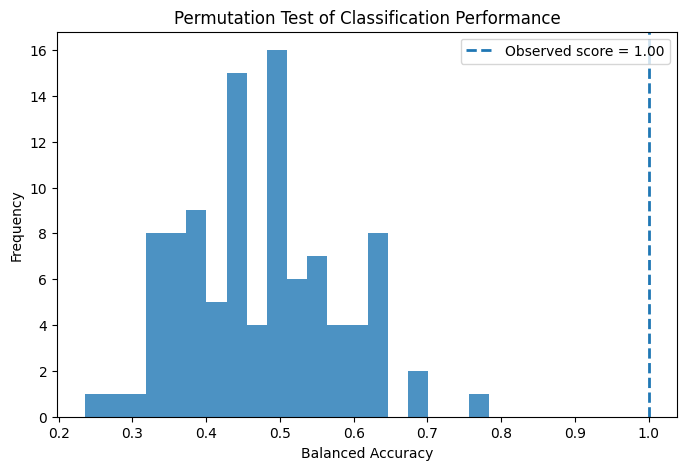

In [153]:
plt.figure(figsize=(8, 5))

plt.hist(
    permutation_scores,
    bins=20,
    alpha=0.8
)

plt.axvline(
    score,
    linestyle="--",
    linewidth=2,
    label=f"Observed score = {score:.2f}"
)

plt.xlabel("Balanced Accuracy")
plt.ylabel("Frequency")
plt.title("Permutation Test of Classification Performance")
plt.legend()

plt.show()

### Permutation Test Interpretation

The observed balanced accuracy was 1.00, whereas models trained using randomly
permuted disease labels achieved a mean balanced accuracy of approximately 0.47.

The permutation test produced a p-value of 0.0099. With 100 permutations, this is the smallest attainable p-value using this procedure; using more permutations would provide finer resolution of the empirical p-value but would not change the interpretation of the present result.

These results suggest that the strong classification performance is associated
with genuine structure between the expression profiles and disease labels
within this dataset rather than being routinely reproduced after random label
assignment.

However, this finding should be interpreted cautiously. The dataset contains
only 18 samples, and cross-validation does not substitute for evaluation in an
independent external cohort. The results therefore demonstrate strong
within-dataset separation rather than validated diagnostic performance.

## 11. Sensitivity to Number of Selected Features

To assess whether classification performance was highly dependent on the
number of expression features selected, the Logistic Regression pipeline was
evaluated using several predefined feature-set sizes.

The purpose of this analysis was to assess robustness to the feature-selection
parameter rather than to select the value producing the highest score.

In [154]:
feature_counts = [10, 25, 50, 100, 250]

sensitivity_results = []

for k in feature_counts:

    pipeline = Pipeline([
        ("variance_filter", VarianceThreshold(threshold=0.1)),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k)),
        ("scaling", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ))
    ])

    results = cross_validate(
        pipeline,
        X_log,
        y,
        cv=cv,
        scoring=scoring
    )

    sensitivity_results.append({
        "Features": k,
        "Balanced Accuracy":
            results["test_balanced_accuracy"].mean(),
        "F1":
            results["test_f1"].mean(),
        "ROC-AUC":
            results["test_roc_auc"].mean()
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,Features,Balanced Accuracy,F1,ROC-AUC
0,10,1.0,1.0,1.0
1,25,1.0,1.0,1.0
2,50,1.0,1.0,1.0
3,100,1.0,1.0,1.0
4,250,1.0,1.0,1.0


### Sensitivity Analysis Interpretation

Classification performance remained unchanged across all predefined feature-set
sizes. Models using 10, 25, 50, 100, and 250 selected expression features all
achieved a mean balanced accuracy, macro F1-score, and ROC-AUC of 1.00.

This indicates that the observed within-dataset separation is not dependent on
the initial choice of 50 selected features and suggests that strong
discriminatory information is present among a relatively small subset of
expression probes.

Nevertheless, these results should be interpreted cautiously because the
dataset contains only 18 samples. Testing several feature-set sizes does not
provide independent validation, and consistently high cross-validation
performance may still reflect dataset-specific biological or technical
structure.

## 12. Exploratory Feature Interpretation

Following model evaluation, an exploratory analysis was performed to identify
expression probes showing strong associations with disease status.

Feature scores were calculated using the complete dataset for descriptive
interpretation only. Because disease labels from all samples are used at this
stage, these rankings are not used to estimate predictive performance and
should not be interpreted as independently validated biomarkers.

The resulting probe identifiers were subsequently linked to platform
annotations to investigate their corresponding genes and biological meaning.

In [155]:
# Encode disease status for exploratory feature scoring

y_binary = y.map({
    "Control": 0,
    "Parkinson's": 1
})

print(y_binary.value_counts())

Group
1    10
0     8
Name: count, dtype: int64


In [156]:
# Apply the same low-variance criterion used in the modelling pipeline
variance_filter = VarianceThreshold(threshold=0.1)

X_filtered_array = variance_filter.fit_transform(X_log)

retained_mask = variance_filter.get_support()
retained_probe_ids = X_log.columns[retained_mask]

X_filtered = pd.DataFrame(
    X_filtered_array,
    index=X_log.index,
    columns=retained_probe_ids
)

print("Features before filtering:", X_log.shape[1])
print("Features retained:", X_filtered.shape[1])

Features before filtering: 41000
Features retained: 26754


In [157]:
# Calculate ANOVA F-scores for exploratory feature ranking

f_scores, p_values = f_classif(X_filtered, y_binary)

feature_scores = pd.DataFrame({
    "Probe_ID": X_filtered.columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

feature_scores = (
    feature_scores
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("F_Score", ascending=False)
    .reset_index(drop=True)
)

feature_scores.head(20)

,Probe_ID,F_Score,P_Value
0,A_32_P64263,1010.159661,6.908281e-16
1,A_32_P76441,629.567308,2.827253e-14
2,A_32_P8857,570.578188,6.092314e-14
3,A_32_P202588,452.946260,3.662380e-13
4,A_32_P162760,406.908330,8.385311e-13
5,A_32_P54260,373.953978,1.607024e-12
6,A_32_P207390,354.678736,2.413103e-12
7,A_32_P135790,348.867324,2.739149e-12
8,A_24_P299007,340.321769,3.312593e-12
9,A_24_P600087,322.558082,4.992476e-12


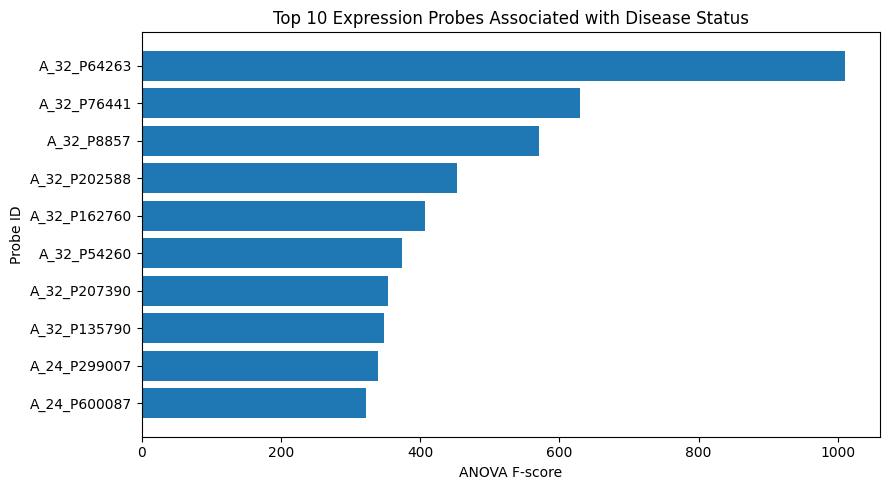

In [158]:
# Display the ten highest-scoring probes

top_10 = feature_scores.head(10).copy()

plt.figure(figsize=(9, 5))

plt.barh(
    top_10["Probe_ID"][::-1],
    top_10["F_Score"][::-1]
)

plt.xlabel("ANOVA F-score")
plt.ylabel("Probe ID")
plt.title("Top 10 Expression Probes Associated with Disease Status")

plt.tight_layout()
plt.show()

### Probe Annotation

The expression matrix contains microarray probe identifiers rather than
direct gene symbols. To support biological interpretation, probe identifiers
were mapped to annotation information from the corresponding GEO platform,
GPL6480.

Probe-to-gene mapping was treated cautiously because microarray probes may map
to genes, transcripts, genomic regions, or may lack a current gene annotation.

In [159]:
# Download the GPL6480 platform annotation from NCBI GEO

platform_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/"
    "GPL6nnn/GPL6480/annot/GPL6480.annot.gz"
)

platform_file = "GPL6480.annot.gz"

urllib.request.urlretrieve(platform_url, platform_file)

print("Platform annotation downloaded successfully.")

Platform annotation downloaded successfully.


In [160]:
# Find the row where the actual data table begins
# Search for the header line which typically starts with "ID" or "ID_REF"
skip_header_lines = 0
header_found = False
with gzip.open(platform_file, "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("ID\t") or line.startswith("ID_REF\t"):
            skip_header_lines = i  # This line is the header
            header_found = True
            break
        # Adding a safeguard to prevent reading huge files if the string isn't found
        if i > 500:  # Check first 500 lines for the header marker
            print("Warning: Header line (starting with 'ID' or 'ID_REF') not found in first 500 lines. Attempting to read with default parameters and comment='#'.")
            skip_header_lines = 0  # Revert to not skipping specific lines if not found
            break

# Load the annotation DataFrame
# If a header was found, skip to that line and use it as the header
# Otherwise, fall back to simple comment skipping
if header_found:
    annotation_df = pd.read_csv(
        platform_file,
        sep="\t",
        compression="gzip",
        skiprows=skip_header_lines, # Skip lines *before* the header
        header=0,  # Use the first skipped line as the header
        low_memory=False
    )
else:
    annotation_df = pd.read_csv(
        platform_file,
        sep="\t",
        compression="gzip",
        comment="#",  # Fallback to skipping lines starting with #
        low_memory=False
    )

print("Annotation shape:", annotation_df.shape)
print("\nAvailable annotation columns:")
print(annotation_df.columns.tolist())

Annotation shape: (41109, 22)

Available annotation columns:
['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID', 'Platform_SEQUENCE']


In [161]:
annotation_df.head()

,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID,Platform_SEQUENCE
0,A_23_P100001,family with sequence similarity 174 member B,FAM174B,400451,NaN,NaN,NaN,Homo sapiens family with sequence similarity 1...,1.501707e+08,NM_207446,...,A_23_P100001,15q26.1,"Chromosome 15, NC_000015.10 (92617447..9273421...",NaN,NaN,integral component of membrane,NaN,NaN,GO:0016021,ATCTCATGGAAAAGCTGGATTCCTCTGCCTTACGCAGAAACACCCG...
1,A_23_P100011,adaptor related protein complex 3 sigma 2 subunit,AP3S2,10239,NaN,NaN,NaN,Homo sapiens adaptor related protein complex 3...,1.894091e+08,NM_005829,...,A_23_P100011,15q26.1,"Chromosome 15, NC_000015.10 (89830599..8989438...",protein transporter activity,anterograde axonal transport///anterograde syn...,AP-3 adaptor complex///Golgi apparatus///axon ...,GO:0008565,GO:0008089///GO:0048490///GO:0006886,GO:0030123///GO:0005794///GO:1904115///GO:0030...,TCAAGTATTGGCCTGACATAGAGTCCTTAAGACAAGCAAAGACAAG...
2,A_23_P100022,synaptic vesicle glycoprotein 2B,SV2B,9899,NaN,NaN,NaN,Homo sapiens synaptic vesicle glycoprotein 2B ...,1.019367e+09,NM_014848,...,A_23_P100022,15q26.1,"Chromosome 15, NC_000015.10 (91099588..91301309)",protein binding///transmembrane transporter ac...,neurotransmitter transport///transmembrane tra...,acrosomal vesicle///cell junction///integral c...,GO:0005515///GO:0022857,GO:0006836///GO:0055085,GO:0001669///GO:0030054///GO:0016021///GO:0016...,ATGTCGGCTGTGGAGGGTTAAAGGGATGAGGCTTTCCTTTGTTTAG...
3,A_23_P100056,RNA binding protein with multiple splicing 2,RBPMS2,348093,NaN,NaN,NaN,Homo sapiens RNA binding protein with multiple...,3.491599e+07,NM_194272,...,A_23_P100056,15q22.31,"Chromosome 15, NC_000015.10 (64739894..6477557...",mRNA binding///nucleotide binding///protein bi...,embryonic digestive tract morphogenesis///nega...,cytoplasm,GO:0003729///GO:0000166///GO:0005515///GO:0042803,GO:0048557///GO:0030514///GO:0051151///GO:0051...,GO:0005737,CCCTGTCAGATAAGTTTAATGTTTAGTTTGAGGCATGAAGAAGAAA...
4,A_23_P100074,apoptosis and caspase activation inhibitor,AVEN,57099,NaN,NaN,NaN,Homo sapiens apoptosis and caspase activation ...,5.669948e+07,NM_020371,...,A_23_P100074,15q13.1,"Chromosome 15, NC_000015.10 (33858602..3407487...",protein binding,apoptotic process///negative regulation of apo...,endomembrane system///intracellular///membrane,GO:0005515,GO:0006915///GO:0043066,GO:0012505///GO:0005622///GO:0016020,GACCAGCCAGTTTACAAGCATGTCTCAAGCTAGTGTGTTCCATTAT...


In [162]:
# Select the annotation fields needed for interpretation

probe_annotation = annotation_df[
    ["ID", "Gene symbol", "Gene title", "Gene ID"]
].copy()

probe_annotation = probe_annotation.rename(
    columns={"ID": "Probe_ID"}
)

# Merge feature scores with GPL6480 gene annotations

annotated_features = feature_scores.merge(
    probe_annotation,
    on="Probe_ID",
    how="left"
)

annotated_features[
    ["Probe_ID", "Gene symbol", "Gene title", "F_Score", "P_Value"]
].head(20)

,Probe_ID,Gene symbol,Gene title,F_Score,P_Value
0,A_32_P64263,NaN,NaN,1010.159661,6.908281e-16
1,A_32_P76441,NaN,NaN,629.567308,2.827253e-14
2,A_32_P8857,NaN,NaN,570.578188,6.092314e-14
3,A_32_P202588,NaN,NaN,452.946260,3.662380e-13
4,A_32_P162760,NaN,NaN,406.908330,8.385311e-13
5,A_32_P54260,NaN,NaN,373.953978,1.607024e-12
6,A_32_P207390,NaN,NaN,354.678736,2.413103e-12
7,A_32_P135790,NaN,NaN,348.867324,2.739149e-12
8,A_24_P299007,NaN,NaN,340.321769,3.312593e-12
9,A_24_P600087,NaN,NaN,322.558082,4.992476e-12


### Multiple-Testing Correction

Because thousands of expression probes were evaluated simultaneously, raw
ANOVA p-values were adjusted using the Benjamini-Hochberg false discovery rate
(FDR) procedure.

The adjusted values are reported as exploratory statistical evidence. Given the
small sample size and the use of the complete dataset for feature ranking, they
should not be interpreted as independently validated biomarkers.

In [163]:
# Benjamini-Hochberg FDR correction

annotated_features["FDR"] = multipletests(
    annotated_features["P_Value"],
    method="fdr_bh"
)[1]

annotated_features[
    [
        "Probe_ID",
        "Gene symbol",
        "Gene title",
        "F_Score",
        "P_Value",
        "FDR"
    ]
].head(20)

,Probe_ID,Gene symbol,Gene title,F_Score,P_Value,FDR
0,A_32_P64263,NaN,NaN,1010.159661,6.908281e-16,1.848242e-11
1,A_32_P76441,NaN,NaN,629.567308,2.827253e-14,3.782016e-10
2,A_32_P8857,NaN,NaN,570.578188,6.092314e-14,5.433126e-10
3,A_32_P202588,NaN,NaN,452.946260,3.662380e-13,2.449583e-09
4,A_32_P162760,NaN,NaN,406.908330,8.385311e-13,4.486812e-09
5,A_32_P54260,NaN,NaN,373.953978,1.607024e-12,7.165718e-09
6,A_32_P207390,NaN,NaN,354.678736,2.413103e-12,9.160398e-09
7,A_32_P135790,NaN,NaN,348.867324,2.739149e-12,9.160398e-09
8,A_24_P299007,NaN,NaN,340.321769,3.312593e-12,9.847234e-09
9,A_24_P600087,NaN,NaN,322.558082,4.992476e-12,1.335687e-08


In [164]:
# Check annotation coverage

mapped = annotated_features["Gene symbol"].notna()
non_empty = (
    annotated_features["Gene symbol"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print("Total ranked probes:", len(annotated_features))
print("Probes with gene symbols:", non_empty.sum())
print(
    "Percentage annotated:",
    round(non_empty.mean() * 100, 1),
    "%"
)

Total ranked probes: 26754
Probes with gene symbols: 19480
Percentage annotated: 72.8 %


In [165]:
top_annotated = (
    annotated_features[non_empty]
    .drop_duplicates(subset="Gene symbol")
    .head(20)
    .copy()
)

top_annotated[
    [
        "Probe_ID",
        "Gene symbol",
        "Gene title",
        "F_Score",
        "P_Value",
        "FDR"
    ]
]

,Probe_ID,Gene symbol,Gene title,F_Score,P_Value,FDR
10,A_32_P128496,SRP9,signal recognition particle 9,314.899251,5.998407e-12,1.344215e-08
11,A_23_P25790,CDH24,cadherin 24,312.911936,6.295411e-12,1.344215e-08
16,A_32_P141135,C1orf74,chromosome 1 open reading frame 74,292.638132,1.048844e-11,1.650633e-08
20,A_24_P233078,PYY2,"peptide YY, 2 (pseudogene)",251.954533,3.261509e-11,4.155163e-08
22,A_23_P433071,BECN1,beclin 1,243.841641,4.174633e-11,4.793954e-08
23,A_23_P400465,GTF3C6,general transcription factor IIIC subunit 6,241.970143,4.424091e-11,4.793954e-08
24,A_24_P369694,PPP2R5C,protein phosphatase 2 regulatory subunit B'gamma,241.569402,4.479661e-11,4.793954e-08
26,A_24_P247106,AK3,adenylate kinase 3,237.688629,5.060411e-11,5.014305e-08
28,A_23_P78061,LHX1,LIM homeobox 1,232.019702,6.067359e-11,5.469456e-08
29,A_32_P162150,TAB3,TGF-beta activated kinase 1/MAP3K7 binding pro...,231.687319,6.133053e-11,5.469456e-08


### Exploratory Biological Interpretation

Approximately 73% of the ranked expression probes could be mapped to a gene
symbol using the GPL6480 platform annotation. Several of the highest-scoring
probes lacked a current gene-symbol annotation and were therefore not assigned
a biological identity.

Among the highly ranked annotated features, BECN1 and DYRK1A are of particular
exploratory interest because both have previously been investigated in
biological pathways relevant to Parkinson's disease.

BECN1 encodes Beclin 1, an important regulator of autophagy. Autophagy and
mitophagy dysfunction have been implicated in Parkinson's disease, and previous
experimental studies have reported interactions between BECN1 and
Parkinson-related proteins and pathways.

DYRK1A encodes a protein kinase that has also been investigated in relation to
Parkinson's disease mechanisms, including regulation of alpha-synuclein and
parkin.

These observations provide biological context for the computational results
but do not establish these genes as biomarkers. Feature ranking was performed
on the complete cohort of only 18 samples, and independent transcriptomic
datasets would be required to determine whether these associations replicate.

In [166]:
# Identify probe IDs for selected genes

genes_to_plot = ["BECN1", "DYRK1A"]

selected_gene_probes = top_annotated[
    top_annotated["Gene symbol"].isin(genes_to_plot)
][["Probe_ID", "Gene symbol"]]

selected_gene_probes

,Probe_ID,Gene symbol
22,A_23_P433071,BECN1
38,A_23_P211126,DYRK1A


In [167]:
# Prepare expression values for selected genes

plot_data = []

for _, row in selected_gene_probes.iterrows():

    probe = row["Probe_ID"]
    gene = row["Gene symbol"]

    temp = pd.DataFrame({
        "Expression": X_log[probe],
        "Group": y,
        "Gene": gene
    })

    plot_data.append(temp)

gene_expression_df = pd.concat(plot_data)

gene_expression_df.head()

,Expression,Group,Gene
GSM558679,10.347036,Control,BECN1
GSM558680,10.468181,Control,BECN1
GSM558681,10.134460,Control,BECN1
GSM558682,10.156557,Control,BECN1
GSM558683,10.361944,Control,BECN1


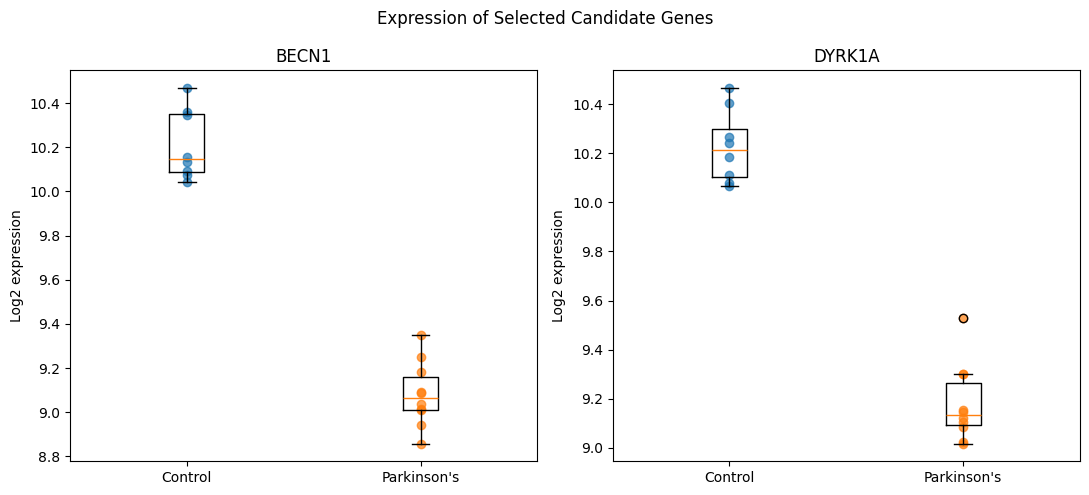

In [168]:
# Visualise expression of selected candidate genes

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, gene in zip(axes, genes_to_plot):

    subset = gene_expression_df[
        gene_expression_df["Gene"] == gene
    ]

    groups = ["Control", "Parkinson's"]

    values = [
        subset.loc[subset["Group"] == group, "Expression"]
        for group in groups
    ]

    ax.boxplot(values, tick_labels=groups)

    # Overlay individual participants
    for position, group_values in enumerate(values, start=1):
        ax.scatter(
            [position] * len(group_values),
            group_values,
            alpha=0.7
        )

    ax.set_title(gene)
    ax.set_ylabel("Log2 expression")

plt.suptitle("Expression of Selected Candidate Genes")
plt.tight_layout()

plt.show()

### Assessment of Potential Confounding

The strong separation observed between Parkinson's disease and control samples
requires careful consideration of potential confounding variables.

Sample metadata were therefore inspected to identify available demographic,
clinical and experimental characteristics that could potentially coincide with
disease status. This is particularly important in a small cohort, where
technical or demographic differences between groups may produce apparent
expression differences.

In [169]:
# Extract sample-level characteristics from the GEO series matrix metadata

characteristic_lines = [
    line.strip()
    for line in lines
    if line.startswith("!Sample_characteristics_ch1")
]

print("Number of characteristic fields:", len(characteristic_lines))

for i, line in enumerate(characteristic_lines, start=1):
    print(f"\nCharacteristic {i}:")
    print(line)

Number of characteristic fields: 2

Characteristic 1:
!Sample_characteristics_ch1	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: control"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"	"patient group: Parkinson’s disease"

Characteristic 2:
!Sample_characteristics_ch1	"cell type: peripheral blood mononuclear cells"	"cell type: peripheral blood mononuclear cells"	"cell type: peripheral blood mononuclear cells"	"cell type: peripheral blood mononuclear cells"	"cell type: peripheral blood mononuclear cells"	"cell type: peripheral blood mononuclear cells"	"cell type: p

In [170]:
# Inspect experimental and processing metadata

metadata_keywords = [
    "!Sample_source_name_ch1",
    "!Sample_description",
    "!Sample_data_processing",
    "!Sample_extract_protocol_ch1",
    "!Sample_label_protocol_ch1",
    "!Sample_hyb_protocol"
]

for keyword in metadata_keywords:

    matches = [
        line.strip()
        for line in lines
        if line.startswith(keyword)
    ]

    if matches:
        print("\n" + "=" * 70)
        print(keyword)

        for match in matches:
            print(match)


!Sample_source_name_ch1
!Sample_source_name_ch1	"Control sample N°1"	"Control sample N°2"	"Control sample N°3"	"Control sample N°4"	"Control sample N°5"	"Control sample N°6"	"Control sample N°7"	"Control sample N°8"	"PD sample # A"	"PD sample # B"	"PD sample # C"	"PD sample # D"	"PD sample # E"	"PD sample # F"	"PD sample # G"	"PD sample # H"	"PD sample # I"	"PD sample # J"

!Sample_description
!Sample_description	"Transcriptomic profiling of peripheral blood mononuclear cells from patients with Parkinson’s disease and control subjects."	"Transcriptomic profiling of peripheral blood mononuclear cells from patients with Parkinson’s disease and control subjects."	"Transcriptomic profiling of peripheral blood mononuclear cells from patients with Parkinson’s disease and control subjects."	"Transcriptomic profiling of peripheral blood mononuclear cells from patients with Parkinson’s disease and control subjects."	"Transcriptomic profiling of peripheral blood mononuclear cells from patients 

### Confounding Assessment

Inspection of the available GEO metadata identified disease group and cell type
as the reported sample-level characteristics. The cohort contained 8 control
samples and 10 Parkinson's disease samples, while all 18 samples were identified
as peripheral blood mononuclear cells (PBMCs).

The available experimental metadata also described a common processing workflow
across samples. PBMCs were isolated using a Ficoll-gradient procedure, RNA was
extracted and quality controlled, Cy3-labelled cRNA was prepared, and samples
were analysed using Agilent whole-human-genome microarrays. The processed
expression intensities were generated using Agilent Feature Extraction software.

No sample-level information on age, sex, BMI, medication, ancestry or an explicit
experimental batch variable was available in the inspected series matrix
metadata. These factors therefore could not be evaluated as potential
confounders.

No obvious technical or cell-type confound was identifiable from the available
metadata. However, the limited reported covariates do not establish the absence
of confounding. The strong separation between Parkinson's disease and control
samples should therefore be interpreted cautiously and evaluated in an
independent cohort.

In [171]:
# Summarise expression differences for selected candidate genes

expression_summary = (
    gene_expression_df
    .groupby(["Gene", "Group"])["Expression"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
)

expression_summary

mean  median    std  count
Gene   Group                                    
BECN1  Control      10.210  10.146  0.159      8
       Parkinson's   9.083   9.063  0.146     10
DYRK1A Control      10.228  10.214  0.148      8
       Parkinson's   9.178   9.133  0.157     10

In [172]:
# Calculate mean log2 expression difference:
# Parkinson's minus Control

candidate_differences = []

for gene in genes_to_plot:

    subset = gene_expression_df[
        gene_expression_df["Gene"] == gene
    ]

    control_mean = subset.loc[
        subset["Group"] == "Control", "Expression"
    ].mean()

    pd_mean = subset.loc[
        subset["Group"] == "Parkinson's", "Expression"
    ].mean()

    candidate_differences.append({
        "Gene": gene,
        "Control_Mean": control_mean,
        "Parkinsons_Mean": pd_mean,
        "Log2_Difference_PD_minus_Control": pd_mean - control_mean
    })

candidate_differences = pd.DataFrame(candidate_differences)

candidate_differences.round(3)

,Gene,Control_Mean,Parkinsons_Mean,Log2_Difference_PD_minus_Control
0,BECN1,10.210,9.083,-1.127
1,DYRK1A,10.228,9.178,-1.049


### Candidate Gene Expression Differences

The selected BECN1 and DYRK1A probes both showed lower expression in the
Parkinson's disease samples than in the control samples.

Mean log2 expression for BECN1 was 10.210 in controls and 9.083 in Parkinson's
disease samples, corresponding to a mean difference of -1.127 log2 units.
For DYRK1A, mean expression was 10.228 in controls and 9.178 in Parkinson's
disease samples, corresponding to a difference of -1.049 log2 units.

These results demonstrate strong group differences for these probes within
this cohort. However, they are exploratory observations from a small dataset
and should not be interpreted as independently validated disease biomarkers.

## 13. Feature-Selection Stability

Because the dataset contains substantially more expression features than
samples, feature rankings may be sensitive to which participants are included
in the training data.

Feature-selection stability was therefore assessed across the 60 training
folds generated by repeated stratified cross-validation. Within each training
fold, variance filtering and ANOVA-based selection were performed using only
the training samples.

The frequency with which each probe was selected among the top 50 features was
then recorded. Higher selection frequency indicates that a probe was repeatedly
identified across different training subsets, although this does not establish
biological or external validity.

In [173]:
selection_counts = Counter()
n_folds = 0

for train_idx, test_idx in cv.split(X_log, y):

    X_train = X_log.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # Fit a fresh copy of the strict pipeline using training data only
    fitted_pipeline = clone(strict_pipeline)
    fitted_pipeline.fit(X_train, y_train)

    # Identify features retained by VarianceThreshold
    variance_step = fitted_pipeline.named_steps["variance_filter"]
    retained_features = X_log.columns[
        variance_step.get_support()
    ]

    # Identify the 50 features selected by SelectKBest
    selection_step = fitted_pipeline.named_steps["feature_selection"]

    selected_features_fold = retained_features[
        selection_step.get_support()
    ]

    selection_counts.update(selected_features_fold)

    n_folds += 1

print("Number of training folds:", n_folds)
print("Feature selections recorded:", sum(selection_counts.values()))

Number of training folds: 60
Feature selections recorded: 3000


In [174]:
stability_df = pd.DataFrame(
    selection_counts.items(),
    columns=["Probe_ID", "Selection_Count"]
)

stability_df["Selection_Frequency"] = (
    stability_df["Selection_Count"] / n_folds
)

stability_df = (
    stability_df
    .sort_values(
        ["Selection_Count", "Probe_ID"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

stability_df.head(20)

,Probe_ID,Selection_Count,Selection_Frequency
0,A_32_P162760,60,1.000000
1,A_32_P202588,60,1.000000
2,A_32_P54260,60,1.000000
3,A_32_P64263,60,1.000000
4,A_32_P76441,60,1.000000
5,A_32_P8857,60,1.000000
6,A_32_P135790,58,0.966667
7,A_32_P72968,57,0.950000
8,A_32_P207390,56,0.933333
9,A_23_P25790,54,0.900000


In [175]:
stability_annotated = stability_df.merge(
    probe_annotation,
    on="Probe_ID",
    how="left"
)

stability_annotated[
    [
        "Probe_ID",
        "Gene symbol",
        "Gene title",
        "Selection_Count",
        "Selection_Frequency"
    ]
].head(20)

,Probe_ID,Gene symbol,Gene title,Selection_Count,Selection_Frequency
0,A_32_P162760,NaN,NaN,60,1.000000
1,A_32_P202588,NaN,NaN,60,1.000000
2,A_32_P54260,NaN,NaN,60,1.000000
3,A_32_P64263,NaN,NaN,60,1.000000
4,A_32_P76441,NaN,NaN,60,1.000000
5,A_32_P8857,NaN,NaN,60,1.000000
6,A_32_P135790,NaN,NaN,58,0.966667
7,A_32_P72968,NaN,NaN,57,0.950000
8,A_32_P207390,NaN,NaN,56,0.933333
9,A_23_P25790,CDH24,cadherin 24,54,0.900000


### Feature-Stability Results

Feature-selection stability analysis identified a subset of probes that were
repeatedly selected across different training subsets.

Six probes were selected in all 60 cross-validation training folds, indicating
that their selection was highly stable within this cohort. Additional probes
also showed high stability, including several selected in more than 90% of
training folds.

Many of the most stable probes did not have an available gene-symbol annotation
in the GPL6480 annotation table. Among the highly stable annotated probes,
CDH24 was selected in 54 of 60 folds (90.0%), while SRP9 was selected in
49 of 60 folds (81.7%).

These results suggest that the strong classification performance is not
dependent on a single feature ranking calculated from the complete dataset.
However, stability across resampled training subsets from the same 18
participants does not demonstrate that these features will generalise to an
independent population or experimental platform.

In [176]:
# Examine stability of selected biologically interesting genes

genes_of_interest = ["BECN1", "DYRK1A"]

stability_annotated[
    stability_annotated["Gene symbol"].isin(genes_of_interest)
][
    [
        "Probe_ID",
        "Gene symbol",
        "Selection_Count",
        "Selection_Frequency"
    ]
]

,Probe_ID,Gene symbol,Selection_Count,Selection_Frequency
20,A_23_P433071,BECN1,38,0.633333
35,A_23_P211126,DYRK1A,21,0.350000


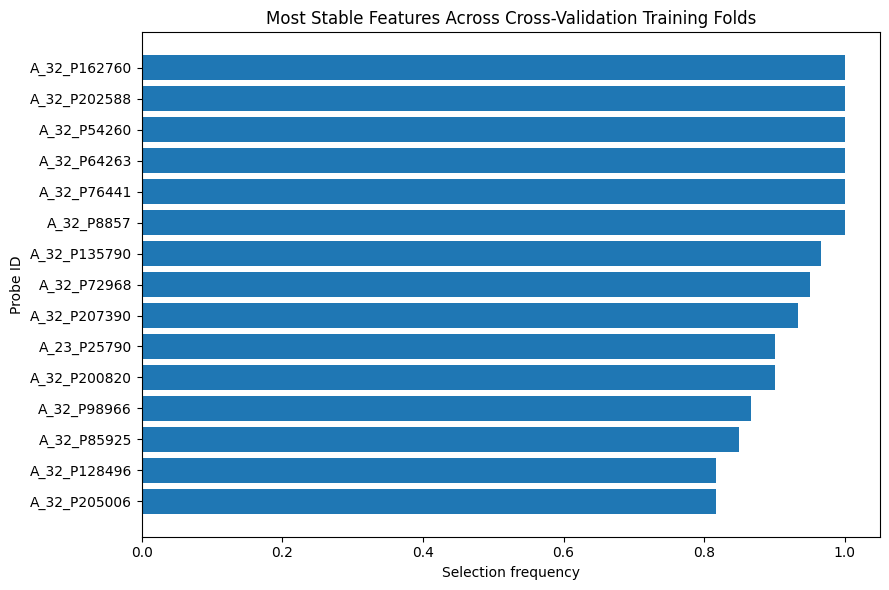

In [177]:
top_stable = stability_df.head(15).copy()

plt.figure(figsize=(9, 6))

plt.barh(
    top_stable["Probe_ID"][::-1],
    top_stable["Selection_Frequency"][::-1]
)

plt.xlabel("Selection frequency")
plt.ylabel("Probe ID")
plt.title("Most Stable Features Across Cross-Validation Training Folds")
plt.xlim(0, 1.05)

plt.tight_layout()
plt.show()

### Stability of Biologically Interesting Candidates

BECN1 was selected in 38 of the 60 cross-validation training folds (63.3%),
indicating moderate feature-selection stability within this cohort. DYRK1A
was selected in 21 folds (35.0%), showing substantially lower stability.

Although both probes showed strong expression differences between Parkinson's
disease and control samples in the complete dataset, they were not among the
most consistently selected features across training subsets.

This illustrates the distinction between biological interpretability and
predictive feature stability. A feature may show a strong group difference or
have relevant biological literature without being one of the most robust
predictors under resampling.

These stability estimates are internal to the same small cohort and therefore
do not establish external reproducibility.

## 14. External Validation Dataset

To assess whether patterns identified in GSE22491 generalise beyond the
development cohort, an independent Parkinson's disease PBMC transcriptomic
dataset (GSE100054) was selected from NCBI GEO.

GSE100054 contains PBMC expression profiles from 9 healthy controls and
10 individuals with Parkinson's disease. Unlike the development dataset,
which was generated using an Agilent microarray platform, GSE100054 was
generated using the Affymetrix Human Clariom D Assay (GPL23126).

Because the datasets use different microarray platforms and therefore
different feature identifiers, direct probe-level prediction is not
appropriate. External validation will instead require mapping both datasets
to common gene identifiers and evaluating the model using genes shared
between the two studies.

The external cohort will remain separate from model development so that its
disease labels are not used for feature selection or model training.

In [178]:
external_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/"
    "GSE100nnn/GSE100054/matrix/"
    "GSE100054_series_matrix.txt.gz"
)

external_compressed = "GSE100054_series_matrix.txt.gz"
external_file = "GSE100054_series_matrix.txt"

urllib.request.urlretrieve(
    external_url,
    external_compressed
)

with gzip.open(external_compressed, "rb") as f_in:
    with open(external_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("External dataset downloaded and extracted successfully.")

External dataset downloaded and extracted successfully.


In [179]:
with open(
    external_file,
    "r",
    encoding="utf-8",
    errors="replace"
) as f:
    external_lines = f.readlines()

print("Number of lines:", len(external_lines))

for i, line in enumerate(external_lines[:80]):
    print(i, line[:200].strip())

Number of lines: 138812
0 !Series_title	"Expression profiling of peripheral blood mononuclear cells in normal controls and patients with Parkinson's disease"
1 !Series_geo_accession	"GSE100054"
2 !Series_status	"Public on Jul 27 2017"
3 !Series_submission_date	"Jun 14 2017"
4 !Series_last_update_date	"Jul 25 2021"
5 !Series_pubmed_id	"29223072"
6 !Series_summary	"Autophagy is a highly conserved degradation pathway whereby not only cytosolic components but also aberrant proteins are sequestered within double-membraned vesicles. Parkinson's dise
7 !Series_overall_design	"PBMC in 9 normal controls and 10 patients with PD were isolated by Ficoll-paque plus (GE Healthcare, 17144002) centrifugation of heparinized blood and frozen at -80 degrees Cel
8 !Series_type	"Expression profiling by array"
9 !Series_contributor	"Yasuo,,Miki"
10 !Series_contributor	"Shuji,,Shimoyama"
11 !Series_sample_id	"GSM2668809 GSM2668810 GSM2668811 GSM2668812 GSM2668813 GSM2668814 GSM2668815 GSM2668816 GSM2668817 G

In [180]:
# Locate the expression matrix in GSE100054

external_start = None
external_end = None

for i, line in enumerate(external_lines):

    if line.startswith('"ID_REF"'):
        external_start = i

    if line.startswith("!series_matrix_table_end"):
        external_end = i
        break

print("Matrix starts at line:", external_start)
print("Matrix ends at line:", external_end)

Matrix starts at line: 65
Matrix ends at line: 138811


In [181]:
external_matrix_text = "".join(
    external_lines[external_start:external_end]
)

external_expression_df = pd.read_csv(
    StringIO(external_matrix_text),
    sep="\t",
    index_col=0
)

print("Expression matrix shape:", external_expression_df.shape)

external_expression_df.head()

Expression matrix shape: (138745, 19)


,GSM2668809,GSM2668810,GSM2668811,GSM2668812,GSM2668813,GSM2668814,GSM2668815,GSM2668816,GSM2668817,GSM2668818,GSM2668819,GSM2668820,GSM2668821,GSM2668822,GSM2668823,GSM2668824,GSM2668825,GSM2668826,GSM2668827
ID_REF,,,,,,,,,,,,,,,,,,,
AFFX-BkGr-GC03_st,10.60950,9.66925,9.15586,9.98873,8.85322,9.86410,7.12550,9.79915,9.75417,8.52454,7.85880,9.13350,9.15586,9.15586,9.79065,8.95471,8.25984,8.66286,9.08873
AFFX-BkGr-GC04_st,8.40165,8.34260,8.19091,8.17589,8.18647,7.72314,7.52711,7.72407,7.72407,7.89668,7.07763,7.38782,7.72407,7.89927,7.45242,7.32761,7.37085,7.59960,7.09682
AFFX-BkGr-GC05_st,7.36409,7.56054,6.96368,6.75987,7.47108,6.75987,6.75987,6.49479,6.75987,6.76431,6.75987,6.75987,6.64173,6.95081,6.53716,6.25158,6.16209,6.75987,6.18880
AFFX-BkGr-GC06_st,6.21929,6.39465,5.97519,5.72257,6.17361,6.06589,5.76089,5.50945,5.73699,5.73699,5.73699,5.73699,5.57749,5.79267,5.37339,5.25114,5.63426,5.67659,5.18252
AFFX-BkGr-GC07_st,5.04645,5.27227,4.79656,4.71968,5.38154,4.88787,4.96678,4.58118,4.72825,4.78507,4.78507,4.78507,4.66051,4.96863,4.64128,4.43702,4.66084,4.78507,4.28517


In [182]:
X_external = external_expression_df.T.copy()

print("External samples:", X_external.shape[0])
print("External features:", X_external.shape[1])

X_external.head()

External samples: 19
External features: 138745


ID_REF,AFFX-BkGr-GC03_st,AFFX-BkGr-GC04_st,AFFX-BkGr-GC05_st,AFFX-BkGr-GC06_st,AFFX-BkGr-GC07_st,AFFX-BkGr-GC08_st,AFFX-BkGr-GC09_st,AFFX-BkGr-GC10_st,AFFX-BkGr-GC11_st,AFFX-BkGr-GC12_st,...,TSUnmapped00000993.hg.1,TSUnmapped00000994.hg.1,TSUnmapped00000995.hg.1,TSUnmapped00000996.hg.1,TSUnmapped00000997.hg.1,TSUnmapped00000998.hg.1,TSUnmapped00000999.hg.1,TSUnmapped00001000.hg.1,TSUnmapped00001001.hg.1,TSUnmapped00001002.hg.1
GSM2668809,10.60950,8.40165,7.36409,6.21929,5.04645,4.52396,3.93883,3.47511,3.14546,2.87249,...,5.21391,5.60227,4.98692,4.80776,10.42730,2.96053,5.35153,9.62366,3.69624,9.38855
GSM2668810,9.66925,8.34260,7.56054,6.39465,5.27227,4.68924,3.90257,3.60057,3.24054,2.93638,...,4.97771,5.43793,3.73179,4.71668,12.20940,2.71443,5.38302,10.95020,3.89925,9.31275
GSM2668811,9.15586,8.19091,6.96368,5.97519,4.79656,4.35998,3.75635,3.33845,3.01265,2.86239,...,4.20849,5.64618,3.53227,4.77275,11.03410,2.43844,5.20835,9.92660,3.89651,9.78011
GSM2668812,9.98873,8.17589,6.75987,5.72257,4.71968,4.18573,3.66965,3.29315,2.97769,2.80536,...,4.91935,5.25031,3.59434,4.99146,9.96832,2.84151,5.30656,9.66863,3.77901,9.88505
GSM2668813,8.85322,8.18647,7.47108,6.17361,5.38154,4.71432,3.95271,3.51170,3.19587,2.92718,...,4.51409,5.54421,4.49432,4.87288,11.51530,2.65340,5.55228,10.12220,3.44962,9.68098


In [183]:
external_title_line = next(
    line for line in external_lines
    if line.startswith("!Sample_title")
)

external_titles = next(
    csv.reader(
        [external_title_line],
        delimiter="\t"
    )
)[1:]

external_sample_info = pd.DataFrame({
    "Sample_ID": X_external.index,
    "Sample_Title": external_titles
})

external_sample_info["Group"] = (
    external_sample_info["Sample_Title"]
    .str.lower()
    .apply(
        lambda x: "Control"
        if x.startswith("control")
        else "Parkinson's"
    )
)

external_sample_info

,Sample_ID,Sample_Title,Group
0,GSM2668809,control 1,Control
1,GSM2668810,control 2,Control
2,GSM2668811,control 3,Control
3,GSM2668812,control 4,Control
4,GSM2668813,control 5,Control
5,GSM2668814,control 6,Control
6,GSM2668815,control 7,Control
7,GSM2668816,control 8,Control
8,GSM2668817,control 9,Control
9,GSM2668818,PD 1,Parkinson's


In [184]:
external_sample_info["Group"].value_counts()

,count
Group,
Parkinson's,10
Control,9


## 15. Cross-Platform Gene Mapping

The development and external datasets were generated using different
microarray platforms. Consequently, their platform-specific probe identifiers
cannot be matched directly.

To enable cross-platform comparison, probe identifiers are mapped to gene
symbols using their respective platform annotations. Where multiple probes
represent the same gene, probe-level measurements will subsequently be
aggregated to produce one expression value per gene and sample.

In [185]:
# Download the official GPL23126 platform annotation from NCBI GEO

external_platform_url = (
    "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi"
    "?acc=GPL23126&targ=self&form=text&view=full"
)

external_platform_file = "GPL23126_full.txt"

urllib.request.urlretrieve(
    external_platform_url,
    external_platform_file
)

print("GPL23126 platform annotation downloaded successfully.")

GPL23126 platform annotation downloaded successfully.


In [186]:
# Inspect the GPL23126 platform file

with open(
    external_platform_file,
    "r",
    encoding="utf-8",
    errors="replace"
) as f:
    platform_lines_external = f.readlines()

print("Number of lines:", len(platform_lines_external))

for i, line in enumerate(platform_lines_external[:80]):
    print(i, line[:250].strip())

Number of lines: 146203
0 ^PLATFORM = GPL23126
1 !Platform_title = [Clariom_D_Human] Affymetrix Human Clariom D Assay [transcript (gene) version]
2 !Platform_geo_accession = GPL23126
3 !Platform_status = Public on Feb 28 2017
4 !Platform_submission_date = Feb 28 2017
5 !Platform_last_update_date = Oct 16 2018
6 !Platform_technology = in situ oligonucleotide
7 !Platform_distribution = commercial
8 !Platform_organism = Homo sapiens
9 !Platform_taxid = 9606
10 !Platform_manufacturer = Affymetrix
11 !Platform_manufacture_protocol = See manufacturers website
12 !Platform_description = Annotation was derived from the Affymetrix annotation file Clariom_D_Human.na36.hg38.transcript.csv:
13 !Platform_description =
14 !Platform_description = #%create_date=Mon Jun 20 14:19:01 2016 PDT
15 !Platform_description = #%chip_type=Clariom_D_Human
16 !Platform_description = #%lib_set_name=Clariom_D_Human
17 !Platform_description = #%lib_set_version=r1
18 !Platform_description = #%genome-species=Homo sapie

In [187]:
# Locate the GPL23126 annotation table

platform_table_start = None
platform_table_end = None

for i, line in enumerate(platform_lines_external):

    if line.startswith("!platform_table_begin"):
        platform_table_start = i

    if line.startswith("!platform_table_end"):
        platform_table_end = i
        break

print("Platform table starts at line:", platform_table_start)
print("Platform table ends at line:", platform_table_end)

Platform table starts at line: 7455
Platform table ends at line: 146202


In [188]:
# Display the beginning of the annotation table

for i in range(
    platform_table_start,
    min(platform_table_start + 8, platform_table_end)
):
    print(i, platform_lines_external[i][:500].strip())

7455 !platform_table_begin
7456 ID	probeset_id	seqname	strand	start	stop	total_probes	gene_assignment	mrna_assignment	swissprot	unigene	GO_biological_process	GO_cellular_component	GO_molecular_function	pathway	protein_domains	category	locus type	SPOT_ID
7457 TC0100006432.hg.1	TC0100006432.hg.1	chr1	+	11869	14412	10	NR_046018 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102 /// OTTHUMT00000002844 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102 /// OTTHUMT00000362751 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102	NR_046018 // RefSeq // Homo sapiens DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 (DDX11L1), non-coding RNA. /
7458 TC0100006433.hg.1	TC0100006433.hg.1	chr1	+	28046	29178	6	spopoybu.aAug10-unspliced // spopoybu // Transcript Identified by AceView // --- // ---	spopoybu.aAug10-unspliced // Ace View // Transcript Identified by AceView // chr1 // 100 /

In [189]:
external_annotation_text = "".join(
    platform_lines_external[
        platform_table_start + 1 : platform_table_end
    ]
)

external_annotation_df = pd.read_csv(
    StringIO(external_annotation_text),
    sep="\t",
    low_memory=False
)

print("Annotation shape:", external_annotation_df.shape)
print("\nColumns:")
print(external_annotation_df.columns.tolist())

external_annotation_df[
    ["ID", "gene_assignment"]
].head(10)

Annotation shape: (138745, 19)

Columns:
['ID', 'probeset_id', 'seqname', 'strand', 'start', 'stop', 'total_probes', 'gene_assignment', 'mrna_assignment', 'swissprot', 'unigene', 'GO_biological_process', 'GO_cellular_component', 'GO_molecular_function', 'pathway', 'protein_domains', 'category', 'locus type', 'SPOT_ID']


,ID,gene_assignment
0,TC0100006432.hg.1,NR_046018 // DDX11L1 // DEAD/H (Asp-Glu-Ala-As...
1,TC0100006433.hg.1,spopoybu.aAug10-unspliced // spopoybu // Trans...
2,TC0100006434.hg.1,NR_036267 // MIR1302-10 // microRNA 1302-10 //...
3,TC0100006435.hg.1,OTTHUMT00000471235 // OR4G4P // olfactory rece...
4,TC0100006436.hg.1,ENST00000492842 // OR4G2P // olfactory recepto...
5,TC0100006437.hg.1,"NM_001005484 // OR4F5 // olfactory receptor, f..."
6,TC0100006438.hg.1,ENST00000442987 // CICP27 // capicua transcrip...
7,TC0100006439.hg.1,---
8,TC0100006440.hg.1,ENST00000496488.1 // RP11-34P13.9 // --- // --...
9,TC0100006441.hg.1,ENST00000624431 // LOC102725121 // putative AT...


In [190]:
for value in (
    external_annotation_df["gene_assignment"]
    .dropna()
    .head(10)
):
    print(value)
    print("-" * 100)

NR_046018 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102 /// OTTHUMT00000002844 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102 /// OTTHUMT00000362751 // DDX11L1 // DEAD/H (Asp-Glu-Ala-Asp/His) box helicase 11 like 1 // 1p36.33 // 100287102
----------------------------------------------------------------------------------------------------
spopoybu.aAug10-unspliced // spopoybu // Transcript Identified by AceView // --- // ---
----------------------------------------------------------------------------------------------------
NR_036267 // MIR1302-10 // microRNA 1302-10 // --- // 100422834 /// ENST00000607096 // MIR1302-2 // microRNA 1302-2 // --- // 100302278
----------------------------------------------------------------------------------------------------
OTTHUMT00000471235 // OR4G4P // olfactory receptor, family 4, subfamily G, member 4 pseudogene // 1p36.33 // 79504
--------------------------------

In [191]:
# Extract the primary gene symbol from GPL23126 gene_assignment

def extract_gene_symbol(assignment):
    if pd.isna(assignment):
        return np.nan

    assignment = str(assignment).strip()

    if assignment == "---" or assignment == "":
        return np.nan

    # Some probes contain multiple gene assignments.
    # Use the first assignment as the primary annotation.
    first_assignment = assignment.split(" /// ")[0]

    parts = first_assignment.split(" // ")

    if len(parts) >= 2:
        gene_symbol = parts[1].strip()

        if gene_symbol not in ["", "---"]:
            return gene_symbol

    return np.nan


external_annotation_df["Gene_Symbol"] = (
    external_annotation_df["gene_assignment"]
    .apply(extract_gene_symbol)
)

external_annotation_df[
    ["ID", "gene_assignment", "Gene_Symbol"]
].head(15)

,ID,gene_assignment,Gene_Symbol
0,TC0100006432.hg.1,NR_046018 // DDX11L1 // DEAD/H (Asp-Glu-Ala-As...,DDX11L1
1,TC0100006433.hg.1,spopoybu.aAug10-unspliced // spopoybu // Trans...,spopoybu
2,TC0100006434.hg.1,NR_036267 // MIR1302-10 // microRNA 1302-10 //...,MIR1302-10
3,TC0100006435.hg.1,OTTHUMT00000471235 // OR4G4P // olfactory rece...,OR4G4P
4,TC0100006436.hg.1,ENST00000492842 // OR4G2P // olfactory recepto...,OR4G2P
5,TC0100006437.hg.1,"NM_001005484 // OR4F5 // olfactory receptor, f...",OR4F5
6,TC0100006438.hg.1,ENST00000442987 // CICP27 // capicua transcrip...,CICP27
7,TC0100006439.hg.1,---,NaN
8,TC0100006440.hg.1,ENST00000496488.1 // RP11-34P13.9 // --- // --...,RP11-34P13.9
9,TC0100006441.hg.1,ENST00000624431 // LOC102725121 // putative AT...,LOC102725121


In [192]:
total_external_features = len(external_annotation_df)

annotated_external_features = (
    external_annotation_df["Gene_Symbol"]
    .notna()
    .sum()
)

unique_external_genes = (
    external_annotation_df["Gene_Symbol"]
    .dropna()
    .nunique()
)

print("Total platform features:", total_external_features)
print("Features with gene symbols:", annotated_external_features)
print(
    "Percentage annotated:",
    round(
        100 * annotated_external_features / total_external_features,
        1
    ),
    "%"
)
print("Unique gene symbols:", unique_external_genes)

Total platform features: 138745
Features with gene symbols: 86161
Percentage annotated: 62.1 %
Unique gene symbols: 81498


In [193]:
expression_feature_ids = set(X_external.columns)
annotation_feature_ids = set(external_annotation_df["ID"])

matched_features = (
    expression_feature_ids &
    annotation_feature_ids
)

print(
    "Expression features:",
    len(expression_feature_ids)
)

print(
    "Annotation features:",
    len(annotation_feature_ids)
)

print(
    "Features matched:",
    len(matched_features)
)

print(
    "Match percentage:",
    round(
        100 * len(matched_features) /
        len(expression_feature_ids),
        2
    ),
    "%"
)

Expression features: 138745
Annotation features: 138745
Features matched: 138745
Match percentage: 100.0 %


In [194]:
# Clean gene symbols from the original Agilent platform

agilent_mapping = probe_annotation[
    ["Probe_ID", "Gene symbol"]
].copy()

agilent_mapping = agilent_mapping.rename(
    columns={"Gene symbol": "Gene_Symbol"}
)

agilent_mapping["Gene_Symbol"] = (
    agilent_mapping["Gene_Symbol"]
    .astype("string")
    .str.strip()
)

agilent_mapping = agilent_mapping[
    agilent_mapping["Gene_Symbol"].notna()
    & (agilent_mapping["Gene_Symbol"] != "")
]

print(
    "Annotated Agilent probes:",
    len(agilent_mapping)
)

print(
    "Unique Agilent gene symbols:",
    agilent_mapping["Gene_Symbol"].nunique()
)

agilent_mapping.head()

Annotated Agilent probes: 30723
Unique Agilent gene symbols: 19565


,Probe_ID,Gene_Symbol
0,A_23_P100001,FAM174B
1,A_23_P100011,AP3S2
2,A_23_P100022,SV2B
3,A_23_P100056,RBPMS2
4,A_23_P100074,AVEN


In [195]:
external_genes = set(
    external_annotation_df["Gene_Symbol"]
    .dropna()
    .astype(str)
    .str.strip()
)

agilent_genes = set(
    agilent_mapping["Gene_Symbol"]
    .dropna()
    .astype(str)
    .str.strip()
)

shared_genes = sorted(
    external_genes.intersection(agilent_genes)
)

print("Agilent genes:", len(agilent_genes))
print("Affymetrix genes:", len(external_genes))
print("Shared genes:", len(shared_genes))

print("\nExample shared genes:")
print(shared_genes[:30])

Agilent genes: 19565
Affymetrix genes: 81498
Shared genes: 18770

Example shared genes:
['A1BG-AS1', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL2', 'AADAT', 'AAED1', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AANAT', 'AAR2', 'AARD', 'AARS', 'AARS2', 'AASDH', 'AASDHPPT', 'AASS', 'AATBC', 'AATF', 'AATK', 'ABAT', 'ABCA1', 'ABCA10']


In [196]:
for gene in ["BECN1", "DYRK1A", "CDH24", "SRP9"]:
    print(
        gene,
        "->",
        "Shared" if gene in shared_genes else "Not shared"
    )

BECN1 -> Shared
DYRK1A -> Shared
CDH24 -> Shared
SRP9 -> Shared


In [197]:
# Convert GSE22491 from Agilent probe-level to gene-level expression

agilent_probe_to_gene = (
    agilent_mapping
    .drop_duplicates(subset=["Probe_ID"])
    .set_index("Probe_ID")["Gene_Symbol"]
)

# Keep only expression probes that have a gene annotation
agilent_annotated_probes = [
    probe for probe in X_log.columns
    if probe in agilent_probe_to_gene.index
]

X_train_annotated = X_log[
    agilent_annotated_probes
].copy()

# Replace probe IDs with gene symbols
X_train_annotated.columns = [
    agilent_probe_to_gene[probe]
    for probe in X_train_annotated.columns
]

# Multiple probes may represent the same gene.
# Average them to obtain one expression value per gene.
X_train_gene = (
    X_train_annotated.T
    .groupby(level=0)
    .mean()
    .T
)

print("Original probe-level shape:", X_log.shape)
print("Gene-level training shape:", X_train_gene.shape)

X_train_gene.iloc[:5, :10]

Original probe-level shape: (18, 41000)
Gene-level training shape: (18, 19565)


,A1BG,A1BG-AS1,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC
GSM558679,10.516290,8.992618,2.207343,6.160983,7.391725,3.063283,2.452700,9.152939,8.851583,2.203523
GSM558680,10.760605,8.763343,1.917897,4.828376,7.234833,3.468330,2.051178,9.079401,8.994620,1.794691
GSM558681,10.645019,8.981950,2.158395,4.722415,7.116195,2.263098,2.361831,8.621998,9.097540,2.115200
GSM558682,10.572257,8.792629,2.184818,3.881127,7.428895,2.793135,1.937770,8.186117,8.741931,1.540026
GSM558683,10.592051,8.984038,3.515360,4.228235,7.541984,1.904641,2.166181,8.899657,8.986928,1.741135


In [198]:
# Create Affymetrix feature-to-gene mapping

external_mapping = (
    external_annotation_df[
        ["ID", "Gene_Symbol"]
    ]
    .dropna(subset=["Gene_Symbol"])
    .drop_duplicates(subset=["ID"])
    .set_index("ID")["Gene_Symbol"]
)

external_annotated_features = [
    feature for feature in X_external.columns
    if feature in external_mapping.index
]

X_external_annotated = X_external[
    external_annotated_features
].copy()

# Replace platform feature IDs with gene symbols
X_external_annotated.columns = [
    external_mapping[feature]
    for feature in external_annotated_features
]

# Average multiple features representing the same gene
X_external_gene = (
    X_external_annotated.T
    .groupby(level=0)
    .mean()
    .T
)

print(
    "Original external feature-level shape:",
    X_external.shape
)

print(
    "Gene-level external shape:",
    X_external_gene.shape
)

X_external_gene.iloc[:5, :10]

Original external feature-level shape: (19, 138745)
Gene-level external shape: (19, 81498)


,5S_rRNA,5_8S_rRNA,7SK,A1BG-AS1,A1CF,A2BP1,A2M,A2M-AS1,A2ML1,A2ML1-AS1
GSM2668809,4.330684,7.924597,4.109045,5.37469,2.90968,3.601953,3.74217,6.53272,3.59048,3.81339
GSM2668810,4.216077,8.049380,3.963647,5.18399,2.63540,3.878347,3.46661,6.82552,3.79140,4.26244
GSM2668811,4.153261,8.055237,3.983300,5.38103,3.01355,3.342623,3.31584,5.69778,3.49025,4.81488
GSM2668812,4.283869,7.815483,4.557535,5.31784,3.30656,3.353970,3.72209,6.65936,3.28707,4.75386
GSM2668813,4.078733,8.127903,4.056713,4.79120,2.82606,3.320043,4.12106,5.01933,3.78564,3.85693


In [199]:
common_genes = sorted(
    set(X_train_gene.columns)
    .intersection(X_external_gene.columns)
)

X_train_common = X_train_gene[
    common_genes
].copy()

X_external_common = X_external_gene[
    common_genes
].copy()

print("Common genes:", len(common_genes))

print(
    "Training matrix:",
    X_train_common.shape
)

print(
    "External matrix:",
    X_external_common.shape
)

print(
    "Columns identical:",
    X_train_common.columns.equals(
        X_external_common.columns
    )
)

Common genes: 18770
Training matrix: (18, 18770)
External matrix: (19, 18770)
Columns identical: True


## 16. Cross-Platform Expression Quality Control

Although the development and external datasets have been mapped to a common
gene space, they were generated using different microarray technologies and
preprocessing procedures.

Before external prediction, the distributions of gene-expression values were
therefore compared between datasets. This step assesses whether substantial
platform-related differences are present and informs the preprocessing strategy
used for cross-platform validation.

In [200]:
# Summarise expression distributions for every sample

train_distribution = pd.DataFrame({
    "Dataset": "GSE22491",
    "Group": y,
    "Mean": X_train_common.mean(axis=1),
    "Median": X_train_common.median(axis=1),
    "Std": X_train_common.std(axis=1),
    "Min": X_train_common.min(axis=1),
    "Max": X_train_common.max(axis=1)
})

y_external = (
    external_sample_info
    .set_index("Sample_ID")
    .loc[X_external_common.index, "Group"]
)

external_distribution = pd.DataFrame({
    "Dataset": "GSE100054",
    "Group": y_external,
    "Mean": X_external_common.mean(axis=1),
    "Median": X_external_common.median(axis=1),
    "Std": X_external_common.std(axis=1),
    "Min": X_external_common.min(axis=1),
    "Max": X_external_common.max(axis=1)
})

distribution_summary = pd.concat([
    train_distribution,
    external_distribution
])

distribution_summary.round(3)

,Dataset,Group,Mean,Median,Std,Min,Max
GSM558679,GSE22491,Control,6.785,6.830,3.623,2.106,18.287
GSM558680,GSE22491,Control,6.821,6.965,3.729,1.755,18.472
GSM558681,GSE22491,Control,6.795,6.901,3.576,2.072,18.315
GSM558682,GSE22491,Control,6.636,6.751,3.638,1.539,18.758
GSM558683,GSE22491,Control,6.741,6.861,3.598,1.737,18.463
GSM558684,GSE22491,Control,6.714,6.877,3.616,1.838,18.177
GSM558685,GSE22491,Control,6.725,6.899,3.692,1.631,18.401
GSM558686,GSE22491,Control,6.849,6.921,3.559,2.022,18.169
GSM558687,GSE22491,Parkinson's,6.455,6.347,3.436,2.153,18.603
GSM558688,GSE22491,Parkinson's,6.521,6.665,3.580,1.688,18.657


In [201]:
distribution_summary.groupby("Dataset")[
    ["Mean", "Median", "Std", "Min", "Max"]
].mean().round(3)

,Mean,Median,Std,Min,Max
Dataset,,,,,
GSE100054,6.985,6.210,3.509,2.297,19.932
GSE22491,6.621,6.702,3.605,1.786,18.525


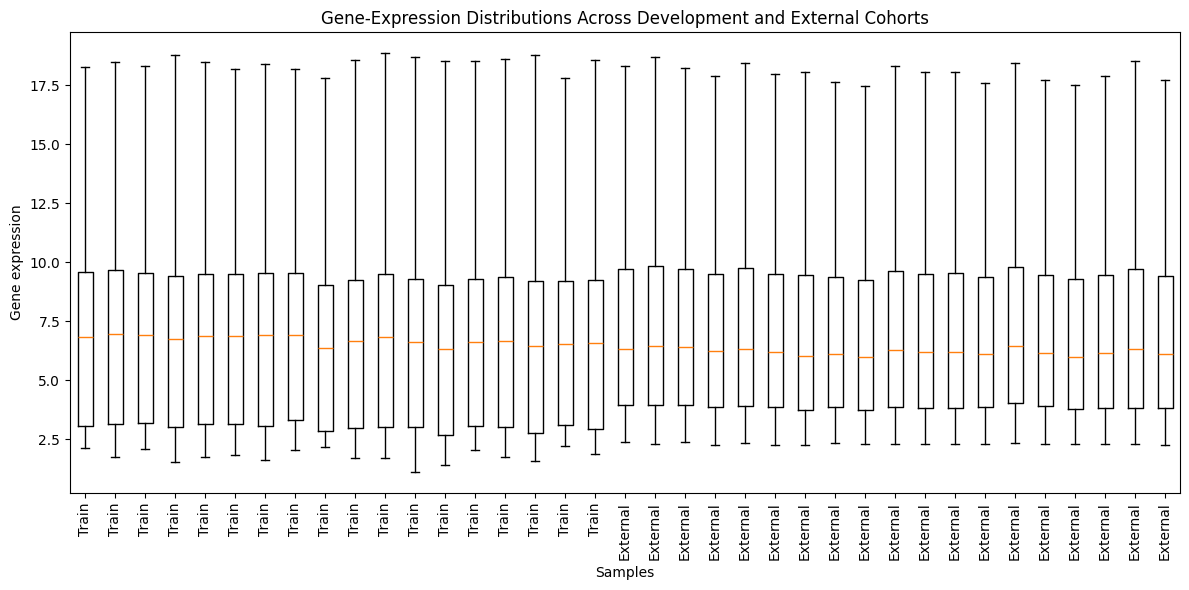

In [202]:
plt.figure(figsize=(12, 6))

combined_expression = [
    X_train_common.loc[sample].values
    for sample in X_train_common.index
] + [
    X_external_common.loc[sample].values
    for sample in X_external_common.index
]

sample_labels = (
    ["Train"] * len(X_train_common)
    + ["External"] * len(X_external_common)
)

plt.boxplot(
    combined_expression,
    showfliers=False,
    tick_labels=sample_labels
)

plt.ylabel("Gene expression")
plt.xlabel("Samples")
plt.title(
    "Gene-Expression Distributions Across Development and External Cohorts"
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Cross-Platform Standardisation

The two cohorts showed broadly comparable expression ranges but differences
in their overall distributions remained, consistent with their use of
different microarray platforms and preprocessing pipelines.

To reduce dependence on platform-specific expression scales, gene-expression
values were standardised independently within each sample. For each sample,
expression values were centred using that sample's mean and scaled by its
standard deviation.

This transformation was performed without using disease labels and without
combining the development and external cohorts during parameter estimation.

In [203]:
# Standardise gene expression independently within each sample

def standardise_within_sample(df):
    sample_means = df.mean(axis=1)
    sample_stds = df.std(axis=1)

    return df.sub(
        sample_means,
        axis=0
    ).div(
        sample_stds,
        axis=0
    )


X_train_crossplatform = standardise_within_sample(
    X_train_common
)

X_external_crossplatform = standardise_within_sample(
    X_external_common
)

print(
    "Training shape:",
    X_train_crossplatform.shape
)

print(
    "External shape:",
    X_external_crossplatform.shape
)

print(
    "Columns identical:",
    X_train_crossplatform.columns.equals(
        X_external_crossplatform.columns
    )
)

Training shape: (18, 18770)
External shape: (19, 18770)
Columns identical: True


In [204]:
standardisation_check = pd.DataFrame({
    "Train_Mean": X_train_crossplatform.mean(axis=1),
    "Train_SD": X_train_crossplatform.std(axis=1)
})

external_standardisation_check = pd.DataFrame({
    "External_Mean": X_external_crossplatform.mean(axis=1),
    "External_SD": X_external_crossplatform.std(axis=1)
})

print("Training:")
display(
    standardisation_check.round(3).head()
)

print("\nExternal:")
display(
    external_standardisation_check.round(3).head()
)

Training:


,Train_Mean,Train_SD
GSM558679,0.0,1.0
GSM558680,-0.0,1.0
GSM558681,0.0,1.0
GSM558682,-0.0,1.0
GSM558683,0.0,1.0



External:


,External_Mean,External_SD
GSM2668809,-0.0,1.0
GSM2668810,0.0,1.0
GSM2668811,0.0,1.0
GSM2668812,0.0,1.0
GSM2668813,-0.0,1.0


## 17. Independent External Validation

A final classification model was developed using only the GSE22491
development cohort. GSE100054 was retained as an independent external
validation cohort and was not used for feature selection or model fitting.

Within the development cohort, low-variance genes were removed and the
50 genes showing the strongest ANOVA associations with disease status were
selected. These genes were then used to train a logistic regression
classifier.

The fitted pipeline was subsequently applied without refitting to the
corresponding genes in GSE100054. External performance therefore assesses
whether the expression patterns learned from GSE22491 transfer to an
independent cohort generated using a different microarray platform.

In [205]:
external_validation_pipeline = Pipeline([
    (
        "variance_filter",
        VarianceThreshold(threshold=0.1)
    ),
    (
        "feature_selection",
        SelectKBest(
            score_func=f_classif,
            k=50
        )
    ),
    (
        "scaling",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        )
    )
])

external_validation_pipeline.fit(
    X_train_crossplatform,
    y
)

print("Final model fitted using GSE22491 only.")

Final model fitted using GSE22491 only.


In [206]:
variance_step = (
    external_validation_pipeline
    .named_steps["variance_filter"]
)

genes_after_variance = (
    X_train_crossplatform.columns[
        variance_step.get_support()
    ]
)

selection_step = (
    external_validation_pipeline
    .named_steps["feature_selection"]
)

selected_external_validation_genes = (
    genes_after_variance[
        selection_step.get_support()
    ]
)

print(
    "Number of selected genes:",
    len(selected_external_validation_genes)
)

print("\nSelected genes:")
print(
    selected_external_validation_genes.tolist()
)

Number of selected genes: 50

Selected genes:
['AHSP', 'ALAS2', 'ANXA3', 'ARG1', 'AZU1', 'B3GAT2', 'BTNL8', 'C1orf229', 'CA1', 'CADM3', 'CAMP', 'CEACAM6', 'CHI3L1', 'CLC', 'CYB561D1', 'DEFA3', 'DEFA4', 'ELANE', 'EN2', 'EPB42', 'FAM131C', 'FKBP10', 'GYPB', 'HBA1', 'HBA2', 'HBB', 'HBD', 'HBM', 'HBQ1', 'LINC01278', 'LPAR4', 'LTF', 'MGC45922', 'NEUROG1', 'NEUROG3', 'PI3', 'PLOD2', 'PTMS', 'RHCE', 'RNF182', 'SELENBP1', 'SLC4A1', 'SLC6A10P', 'SLPI', 'SNORA78', 'SPTA1', 'SYCE1L', 'SYNGR4', 'TCN1', 'UCHL1']


In [207]:
external_predictions = (
    external_validation_pipeline.predict(
        X_external_crossplatform
    )
)

external_probabilities = (
    external_validation_pipeline.predict_proba(
        X_external_crossplatform
    )[:, 1]
)

external_results = pd.DataFrame({
    "Sample_ID": X_external_crossplatform.index,
    "True_Group": y_external,
    "Predicted_Group": external_predictions,
    "PD_Probability": external_probabilities
})

external_results

,Sample_ID,True_Group,Predicted_Group,PD_Probability
GSM2668809,GSM2668809,Control,Control,1.629016e-05
GSM2668810,GSM2668810,Control,Control,1.145020e-05
GSM2668811,GSM2668811,Control,Control,1.744457e-06
GSM2668812,GSM2668812,Control,Control,1.610076e-06
GSM2668813,GSM2668813,Control,Control,3.573439e-06
GSM2668814,GSM2668814,Control,Control,1.818442e-05
GSM2668815,GSM2668815,Control,Control,4.370483e-05
GSM2668816,GSM2668816,Control,Control,9.716814e-06
GSM2668817,GSM2668817,Control,Control,5.923102e-06
GSM2668818,GSM2668818,Parkinson's,Control,2.649751e-06


In [208]:
external_accuracy = accuracy_score(
    y_external,
    external_predictions
)

external_balanced_accuracy = balanced_accuracy_score(
    y_external,
    external_predictions
)

external_f1 = f1_score(
    y_external,
    external_predictions,
    pos_label="Parkinson's"
)

external_auc = roc_auc_score(
    (y_external == "Parkinson's").astype(int),
    external_probabilities
)

external_cm = confusion_matrix(
    y_external,
    external_predictions,
    labels=["Control", "Parkinson's"]
)

print("External Accuracy:", round(external_accuracy, 3))
print(
    "External Balanced Accuracy:",
    round(external_balanced_accuracy, 3)
)
print("External Parkinson's F1:", round(external_f1, 3))
print("External ROC-AUC:", round(external_auc, 3))

print("\nConfusion Matrix:")
print(external_cm)

External Accuracy: 0.474
External Balanced Accuracy: 0.5
External Parkinson's F1: 0.0
External ROC-AUC: 0.333

Confusion Matrix:
[[ 9  0]
 [10  0]]


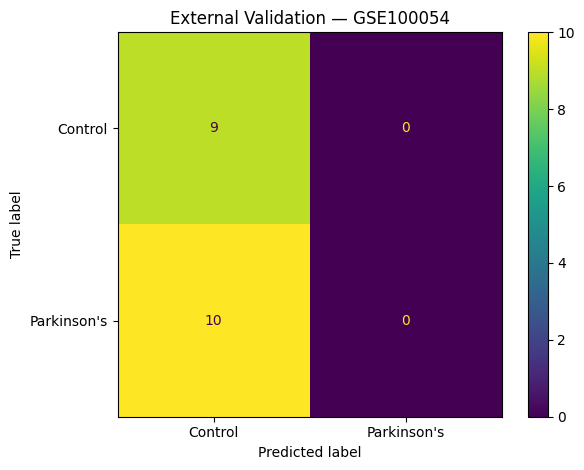

In [209]:
ConfusionMatrixDisplay(
    confusion_matrix=external_cm,
    display_labels=["Control", "Parkinson's"]
).plot()

plt.title("External Validation — GSE100054")
plt.tight_layout()
plt.show()

### External Validation Results

The classifier did not generalise successfully to the independent GSE100054
cohort. All 19 external samples were classified as controls, resulting in an
accuracy of 47.4% and a balanced accuracy of 50.0%. All 9 control samples were
correctly classified, whereas none of the 10 Parkinson's disease samples were
correctly identified, producing a Parkinson's disease F1-score of 0.

The external ROC-AUC was 0.333, indicating that the model also failed to
reliably rank Parkinson's disease samples above controls based on predicted
probabilities. Therefore, the poor external performance cannot be explained
solely by the use of a 0.5 classification threshold.

This result contrasts strongly with the perfect internal cross-validation
performance observed in GSE22491. It suggests that the expression patterns
learned from the small development cohort do not transfer directly to this
independent cohort.

Several factors may contribute to this result, including differences in
microarray platform and preprocessing, cohort characteristics, blood-cell
composition, unmeasured confounding and instability associated with the small
development sample size. The available analysis cannot determine which of
these factors is primarily responsible.

These findings demonstrate the importance of independent validation when
evaluating high-dimensional biomedical machine-learning models.

In [210]:
selected_gene_comparison = pd.DataFrame({
    "Gene": selected_external_validation_genes,

    "GSE22491_Mean": (
        X_train_crossplatform[
            selected_external_validation_genes
        ].mean(axis=0).values
    ),

    "GSE100054_Mean": (
        X_external_crossplatform[
            selected_external_validation_genes
        ].mean(axis=0).values
    )
})

selected_gene_comparison["Mean_Difference"] = (
    selected_gene_comparison["GSE100054_Mean"]
    - selected_gene_comparison["GSE22491_Mean"]
)

selected_gene_comparison["Absolute_Difference"] = (
    selected_gene_comparison["Mean_Difference"].abs()
)

selected_gene_comparison = (
    selected_gene_comparison
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .reset_index(drop=True)
)

selected_gene_comparison.round(3).head(20)

,Gene,GSE22491_Mean,GSE100054_Mean,Mean_Difference,Absolute_Difference
0,SYCE1L,2.281,-1.182,-3.463,3.463
1,EN2,2.150,-1.137,-3.288,3.288
2,SNORA78,2.304,-0.951,-3.255,3.255
3,FAM131C,1.480,-1.097,-2.577,2.577
4,MGC45922,1.483,-0.990,-2.474,2.474
5,C1orf229,1.297,-1.166,-2.464,2.464
6,NEUROG3,1.546,-0.677,-2.223,2.223
7,NEUROG1,0.922,-1.242,-2.164,2.164
8,SYNGR4,0.928,-1.026,-1.954,1.954
9,HBM,0.719,-1.145,-1.865,1.865


In [211]:
print(
    "Mean absolute cross-dataset difference:",
    round(
        selected_gene_comparison[
            "Absolute_Difference"
        ].mean(),
        3
    )
)

print(
    "Median absolute cross-dataset difference:",
    round(
        selected_gene_comparison[
            "Absolute_Difference"
        ].median(),
        3
    )
)

Mean absolute cross-dataset difference: 0.993
Median absolute cross-dataset difference: 0.633


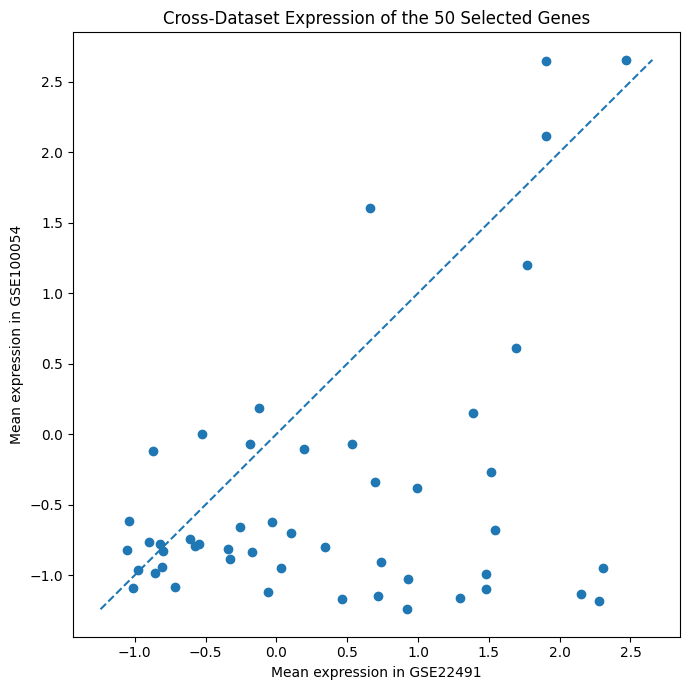

In [212]:
plt.figure(figsize=(7, 7))

plt.scatter(
    selected_gene_comparison["GSE22491_Mean"],
    selected_gene_comparison["GSE100054_Mean"]
)

plt.xlabel("Mean expression in GSE22491")
plt.ylabel("Mean expression in GSE100054")
plt.title("Cross-Dataset Expression of the 50 Selected Genes")

minimum = min(
    selected_gene_comparison["GSE22491_Mean"].min(),
    selected_gene_comparison["GSE100054_Mean"].min()
)

maximum = max(
    selected_gene_comparison["GSE22491_Mean"].max(),
    selected_gene_comparison["GSE100054_Mean"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.tight_layout()
plt.show()

### Cross-Dataset Shift in Selected Features

Comparison of the 50 genes selected using the GSE22491 development cohort
revealed substantial differences in their relative expression between the
development and external datasets.

Across the selected genes, the mean absolute difference in standardised
expression between datasets was 0.993, with a median absolute difference of
0.633. Several genes showed particularly large shifts. For example, SYCE1L
had a mean standardised expression of 2.281 in GSE22491 but -1.182 in
GSE100054, while EN2 shifted from 2.150 to -1.137.

The cross-dataset scatter plot further demonstrated that many selected genes
deviated substantially from the line representing equal mean expression
between cohorts.

These findings provide evidence of substantial dataset-level or platform-level
shift among features selected by the development model. Such differences may
help explain why the classifier trained on GSE22491 failed to generalise to
GSE100054.

However, this analysis cannot determine whether the observed shift results
primarily from microarray platform differences, preprocessing, cohort
composition, biological heterogeneity, or other unmeasured factors.

In [213]:
# Calculate PD-Control differences for the 50 selected genes
# independently within each cohort

effect_comparison = []

for gene in selected_external_validation_genes:

    train_control = X_train_crossplatform.loc[
        y == "Control", gene
    ].mean()

    train_pd = X_train_crossplatform.loc[
        y == "Parkinson's", gene
    ].mean()

    external_control = X_external_crossplatform.loc[
        y_external == "Control", gene
    ].mean()

    external_pd = X_external_crossplatform.loc[
        y_external == "Parkinson's", gene
    ].mean()

    effect_comparison.append({
        "Gene": gene,
        "GSE22491_PD_minus_Control": train_pd - train_control,
        "GSE100054_PD_minus_Control": external_pd - external_control
    })

effect_comparison = pd.DataFrame(effect_comparison)

effect_comparison["Same_Direction"] = (
    np.sign(effect_comparison["GSE22491_PD_minus_Control"])
    ==
    np.sign(effect_comparison["GSE100054_PD_minus_Control"])
)

effect_comparison.round(3)

,Gene,GSE22491_PD_minus_Control,GSE100054_PD_minus_Control,Same_Direction
0,AHSP,-1.269,0.035,False
1,ALAS2,-1.448,0.245,False
2,ANXA3,-0.700,-0.095,True
3,ARG1,-1.073,-0.034,True
4,AZU1,-0.506,-0.097,True
5,B3GAT2,0.650,0.022,True
6,BTNL8,-0.661,0.017,False
7,C1orf229,0.692,0.009,True
8,CA1,-1.082,0.256,False
9,CADM3,0.643,0.008,True


In [214]:
same_direction_count = effect_comparison["Same_Direction"].sum()
total_genes = len(effect_comparison)

print("Genes with same direction:", same_direction_count)
print("Total selected genes:", total_genes)

print(
    "Percentage with same direction:",
    round(100 * same_direction_count / total_genes, 1),
    "%"
)

effect_correlation = effect_comparison[
    [
        "GSE22491_PD_minus_Control",
        "GSE100054_PD_minus_Control"
    ]
].corr().iloc[0, 1]

print(
    "Correlation of PD-Control effects:",
    round(effect_correlation, 3)
)

Genes with same direction: 27
Total selected genes: 50
Percentage with same direction: 54.0 %
Correlation of PD-Control effects: -0.163


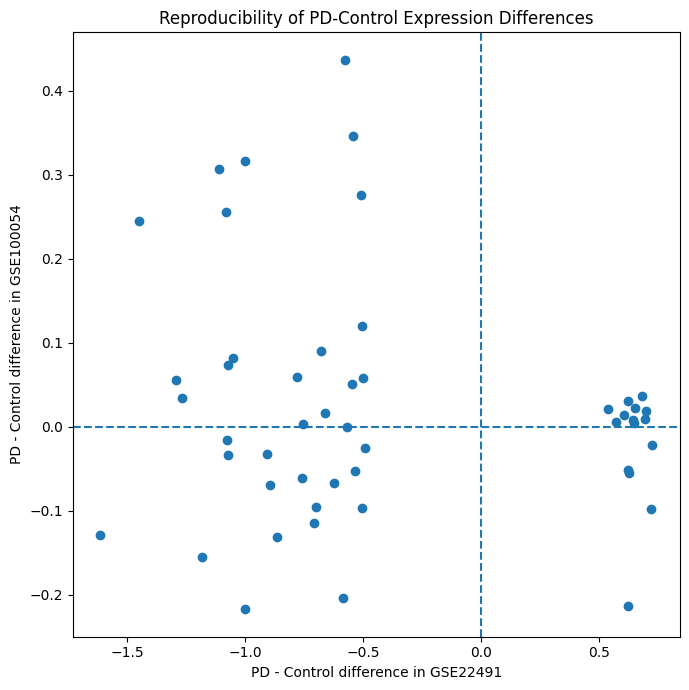

In [215]:
plt.figure(figsize=(7, 7))

plt.scatter(
    effect_comparison["GSE22491_PD_minus_Control"],
    effect_comparison["GSE100054_PD_minus_Control"]
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("PD - Control difference in GSE22491")
plt.ylabel("PD - Control difference in GSE100054")

plt.title(
    "Reproducibility of PD-Control Expression Differences"
)

plt.tight_layout()
plt.show()

### Reproducibility of Disease-Associated Expression Differences

The reproducibility of Parkinson's disease-associated expression differences
was examined for the 50 genes selected from the GSE22491 development cohort.

Of the 50 selected genes, 27 (54%) showed a PD-control difference in the same
direction in GSE100054, while 23 (46%) showed an opposite direction. The
correlation between the PD-control expression differences across the two
datasets was -0.163, indicating little agreement in the magnitude and direction
of the disease-associated effects.

Visual inspection of the effect-comparison plot similarly showed limited
cross-dataset concordance. Although some genes retained the same direction of
effect, many showed weak or reversed differences in the independent cohort.

Together with the external ROC-AUC of 0.333 and the failure to correctly
classify any Parkinson's disease samples, these findings indicate that the
strong expression signature identified within GSE22491 did not reproduce
reliably in GSE100054.

Potential explanations include differences in microarray technology,
preprocessing, cohort characteristics, PBMC cell composition and other
unmeasured confounding factors. The small development sample size may also
have contributed to selection of dataset-specific features. These possibilities
cannot be distinguished conclusively using the available data.

## 18. Discussion

This project investigated whether peripheral blood mononuclear cell (PBMC)
gene-expression profiles could distinguish individuals with Parkinson's
disease from healthy controls using machine-learning methods.

### Internal Model Performance

Analysis of the GSE22491 development cohort identified strong separation
between Parkinson's disease and control samples. PCA showed substantial
group separation, while a logistic regression pipeline incorporating
variance filtering, ANOVA-based feature selection and standardisation
achieved perfect performance under repeated stratified cross-validation.

Permutation testing produced a p-value of approximately 0.0099, indicating
that the observed within-dataset classification performance was unlikely to
arise from random permutation of the disease labels under the implemented
procedure. Feature-selection stability analysis also showed that several
features were repeatedly selected across cross-validation training folds.

However, GSE22491 contained only 18 samples (10 Parkinson's disease and
8 controls) and thousands of expression features. Therefore, perfect
internal classification should not be interpreted as evidence of a clinically
reliable Parkinson's disease classifier.

### Biological Interpretation

Exploratory feature analysis identified several annotated genes associated
with disease status within GSE22491. BECN1 and DYRK1A were examined in
greater detail because they were among annotated features of potential
biological interest.

Both showed clear expression differences between Parkinson's disease and
control samples in the development dataset. However, these analyses used the
complete development dataset and were performed for descriptive
interpretation rather than independent biomarker validation.

The analysis therefore identifies candidate expression patterns rather than
genes that cause Parkinson's disease or validated diagnostic biomarkers.

### Independent External Validation

To assess generalisability, the model was evaluated using the independent
GSE100054 PBMC transcriptomic cohort containing 10 Parkinson's disease and
9 control samples.

Because GSE22491 and GSE100054 were generated using different microarray
platforms, platform-specific features were mapped to gene symbols and
aggregated to gene-level expression. A total of 18,770 genes were shared
between the two datasets.

The classifier was developed using GSE22491 only and then applied without
refitting to GSE100054. External performance was substantially lower than
internal cross-validation performance. Accuracy was 47.4%, balanced accuracy
was 50.0%, Parkinson's disease F1-score was 0, and ROC-AUC was 0.333.
All external samples were classified as controls.

### Cross-Dataset Generalisability

Further investigation identified substantial differences in the selected
features between datasets. Across the 50 genes selected by the development
model, the mean absolute difference in standardised expression between
datasets was 0.993 and the median absolute difference was 0.633.

Disease-associated expression effects also showed limited reproducibility.
Only 27 of the 50 selected genes (54%) showed Parkinson's disease-control
differences in the same direction across both cohorts. The correlation
between disease-associated effects was -0.163.

These findings suggest that the strong signal observed within GSE22491 did
not reproduce reliably in the independent GSE100054 cohort. Possible
contributors include platform and preprocessing differences, cohort
heterogeneity, differences in PBMC cell composition, unmeasured confounding
and instability resulting from the small development sample size.

## 19. Limitations

This study has several important limitations.

First, both datasets contain small numbers of participants relative to the
number of gene-expression features. This creates a substantial risk of
overfitting and unstable feature selection.

Second, the development and external cohorts were generated using different
microarray platforms and preprocessing procedures. Although features were
mapped to common gene symbols and expression was standardised independently
within samples, these steps cannot eliminate all platform-related differences.

Third, the available metadata for GSE22491 were limited. Variables such as
age, sex, BMI, medication, ancestry and explicit experimental batch were not
available at the sample level in the inspected series-matrix metadata.
Consequently, their potential influence could not be evaluated.

Fourth, although all GSE22491 samples were reported as PBMCs, PBMCs contain
multiple immune-cell populations. Differences in cell-type proportions
between participants could contribute to observed expression differences and
were not assessed in this analysis.

Fifth, mapping platform-specific features to gene symbols and averaging
multiple features representing the same gene simplifies complex transcript-
and probe-level information and may introduce additional uncertainty.

Finally, this study is exploratory and does not establish causality or
clinical diagnostic utility. Associations between gene expression and
Parkinson's disease do not demonstrate that the identified genes cause the
disease.

## 20. Conclusion

This project developed and evaluated a reproducible machine-learning workflow
for analysing PBMC gene-expression data in Parkinson's disease.

Strong separation and perfect repeated cross-validation performance were
observed within the small GSE22491 development cohort. However, independent
cross-platform validation using GSE100054 produced an accuracy of 47.4%,
balanced accuracy of 50.0% and ROC-AUC of 0.333, with no Parkinson's disease
samples correctly classified.

Further analysis showed substantial cross-dataset shifts among selected genes
and weak agreement in Parkinson's disease-associated expression differences.
The results therefore demonstrate that strong internal predictive performance
does not necessarily imply generalisability to an independent biomedical
cohort.

Rather than supporting a clinically useful Parkinson's disease classifier,
the study highlights the importance of independent validation, careful
handling of platform differences, confounding assessment and cautious
interpretation of high-dimensional transcriptomic machine-learning results.

Future work could incorporate larger cohorts, richer clinical metadata,
cell-type deconvolution, dedicated cross-platform harmonisation methods and
single-cell transcriptomic data to investigate whether more reproducible
disease-associated signals can be identified.